## Imports

> This analysis reads the latest WVS evaluation outputs and infers the evaluated countries and models dynamically.


In [1]:
import gc
import json
import math
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)

In [2]:
# ----------------------------
# Path configuration
# ----------------------------

# This analysis notebook consumes the output files produced by the latest
# WVS evaluation notebook. Countries and adapter models are inferred from
# those files; they do not need to be listed here.
DATA_DIR = Path("/content/drive/MyDrive/DPO/DPO/eval_new_data")
RESULTS_DIR = DATA_DIR / "eval_results_wvs_wave7_new"

print("WVS evaluation results dir:", RESULTS_DIR)


WVS evaluation results dir: /content/drive/MyDrive/DPO/DPO/eval_new_data/eval_results_wvs_wave7_new


In [6]:
# If running in Google Colab.
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
def read_result_csv(filename, required=True, expected_columns=None):
    """Read one WVS evaluation output, with clean handling of optional files."""
    path = RESULTS_DIR / filename

    if not path.exists():
        if required:
            raise FileNotFoundError(
                f"Required WVS evaluation output not found: {path}. "
                "Run the latest WVS evaluation notebook first or update RESULTS_DIR."
            )
        print(f"Optional result file not found: {path}")
        return pd.DataFrame(columns=list(expected_columns or []))

    try:
        return pd.read_csv(path)
    except pd.errors.EmptyDataError:
        # Some optional specificity outputs can legitimately contain no rows
        # when the evaluation was self-only and no cross-evaluation was run.
        return pd.DataFrame(columns=list(expected_columns or []))


def normalize_country_code(country, available_countries=None):
    """Normalize a country code against the countries actually present."""
    country = str(country).strip().upper()
    available = set(available_countries or [])

    # Preserve compatibility with the older US/USA naming convention.
    if country == "US" and "USA" in available:
        return "USA"
    if country == "USA" and "US" in available:
        return "US"
    return country


In [4]:
# The latest WVS evaluation notebook already writes the population distributions,
# model probabilities, per-question metrics, GPS-dimension summaries, and skipped
# country/question pairs needed below. No country list or raw survey reload is
# required in this analysis notebook.


## Reading files

In [7]:
# ----------------------------
# Read latest WVS evaluation outputs
# ----------------------------

option_evaluation = read_result_csv(
    "survey_option_evaluation_all_models.csv",
    required=True,
)
question_metrics = read_result_csv(
    "survey_question_metrics_all_models.csv",
    required=True,
)

gps_base_comparison_by_question = read_result_csv(
    "survey_adapter_improvement_vs_base_by_question_and_gps_dimension.csv",
    required=False,
)
gps_base_improvement_summary = read_result_csv(
    "survey_adapter_improvement_vs_base_by_gps_dimension.csv",
    required=False,
)
gps_specificity_by_question = read_result_csv(
    "survey_matched_vs_cross_specificity_by_question_and_gps_dimension.csv",
    required=False,
)
gps_specificity_summary = read_result_csv(
    "survey_matched_vs_cross_specificity_by_gps_dimension.csv",
    required=False,
)
gps_moment_summary = read_result_csv(
    "survey_moment_diagnostics_by_gps_dimension.csv",
    required=False,
)
skipped_population_questions = read_result_csv(
    "skipped_population_questions.csv",
    required=False,
)

required_option_columns = {
    "model", "eval_country", "question_id", "option_code",
    "option_index", "population_prob", "model_prob",
}
missing_option_columns = required_option_columns.difference(option_evaluation.columns)
if missing_option_columns:
    raise KeyError(
        "survey_option_evaluation_all_models.csv is missing required columns: "
        f"{sorted(missing_option_columns)}"
    )

required_metric_columns = {"model", "eval_country", "question_id"}
missing_metric_columns = required_metric_columns.difference(question_metrics.columns)
if missing_metric_columns:
    raise KeyError(
        "survey_question_metrics_all_models.csv is missing required columns: "
        f"{sorted(missing_metric_columns)}"
    )

# Preserve the order written by the evaluation notebook rather than imposing a
# fixed list of countries or adapters.
AVAILABLE_EVAL_COUNTRIES = list(
    dict.fromkeys(option_evaluation["eval_country"].dropna().astype(str))
)
AVAILABLE_MODELS = list(
    dict.fromkeys(option_evaluation["model"].dropna().astype(str))
)
ADAPTER_MODELS = [model for model in AVAILABLE_MODELS if model != "base"]

# Infer matched adapter <-> country relationships from the evaluation output.
MATCHED_ADAPTER_BY_COUNTRY = {}
if "relationship" in question_metrics.columns:
    matched_pairs = (
        question_metrics.loc[
            question_metrics["relationship"].astype(str).eq("matched"),
            ["eval_country", "model"],
        ]
        .drop_duplicates()
    )
    for country, group in matched_pairs.groupby("eval_country", sort=False):
        models = group["model"].astype(str).drop_duplicates().tolist()
        if len(models) == 1:
            MATCHED_ADAPTER_BY_COUNTRY[str(country)] = models[0]
        elif len(models) > 1:
            print(
                f"Warning: multiple matched adapters found for {country}: {models}. "
                "No unique matched adapter will be assumed."
            )

# Fallback for outputs that do not contain a relationship column.
for country in AVAILABLE_EVAL_COUNTRIES:
    if country in MATCHED_ADAPTER_BY_COUNTRY:
        continue
    candidates = [f"{country}_adapter"]
    if country == "USA":
        candidates.append("US_adapter")
    elif country == "US":
        candidates.append("USA_adapter")
    for candidate in candidates:
        if candidate in ADAPTER_MODELS:
            MATCHED_ADAPTER_BY_COUNTRY[country] = candidate
            break

ADAPTER_TO_MATCHED_COUNTRY = {
    adapter: country for country, adapter in MATCHED_ADAPTER_BY_COUNTRY.items()
}
MATCHED_ADAPTER_MODELS = [
    model for model in ADAPTER_MODELS if model in ADAPTER_TO_MATCHED_COUNTRY
]

# Backward-compatible names used by a few plotting examples below.
DATA_COUNTRY_CODES = AVAILABLE_EVAL_COUNTRIES
ADAPTER_COUNTRY_CODES = [
    model[:-8] if model.endswith("_adapter") else model
    for model in ADAPTER_MODELS
]

print(f"Countries found ({len(AVAILABLE_EVAL_COUNTRIES)}): {AVAILABLE_EVAL_COUNTRIES}")
print(f"Models found ({len(AVAILABLE_MODELS)}): {AVAILABLE_MODELS}")
print("Matched adapters inferred from results:")
for country in AVAILABLE_EVAL_COUNTRIES:
    print(f"  {country}: {MATCHED_ADAPTER_BY_COUNTRY.get(country, '<none in this run>')}")

if not skipped_population_questions.empty:
    print(
        f"Skipped country/question pairs recorded by WVS evaluation: "
        f"{len(skipped_population_questions)}"
    )


Countries found (8): ['CHN', 'JPN', 'GBR', 'USA', 'MEX', 'ARG', 'DEU', 'RUS']
Models found (9): ['base', 'CHN_adapter', 'JPN_adapter', 'GBR_adapter', 'USA_adapter', 'MEX_adapter', 'ARG_adapter', 'DEU_adapter', 'RUS_adapter']
Matched adapters inferred from results:
  CHN: CHN_adapter
  JPN: JPN_adapter
  GBR: GBR_adapter
  USA: USA_adapter
  MEX: MEX_adapter
  ARG: ARG_adapter
  DEU: DEU_adapter
  RUS: RUS_adapter
Skipped country/question pairs recorded by WVS evaluation: 1


In [8]:
model_generated_answers = read_result_csv(
    "model_generated_answers_and_prompts.csv",
    required=False,
)

if model_generated_answers.empty:
    print("No generated-answer output is available for this evaluation run.")
else:
    print(f"Loaded {len(model_generated_answers):,} generated-answer rows.")


Loaded 558 generated-answer rows.


## Plots & analysis

## Visualization functions

In [9]:
def plot_question_distribution(question_id, eval_country, model_names=None):
    """Plot population and every available model for one country/question pair."""
    eval_country = normalize_country_code(eval_country, AVAILABLE_EVAL_COUNTRIES)

    subset = option_evaluation.loc[
        option_evaluation["question_id"].eq(question_id)
        & option_evaluation["eval_country"].astype(str).eq(eval_country)
    ].copy()

    if subset.empty:
        print(f"No results found for {question_id} / {eval_country}; skipping plot.")
        return None

    available_here = list(dict.fromkeys(subset["model"].astype(str)))
    if model_names is None:
        model_names = available_here
    else:
        requested = [str(model) for model in model_names]
        missing = [model for model in requested if model not in available_here]
        if missing:
            print(f"Skipping unavailable models for {eval_country}/{question_id}: {missing}")
        model_names = [model for model in requested if model in available_here]

    if not model_names:
        print(f"No requested models are available for {question_id} / {eval_country}.")
        return None

    first_model = model_names[0]
    population = (
        subset.loc[subset["model"].astype(str).eq(first_model)]
        .sort_values("option_index")
        .copy()
    )
    codes = population["option_code"].astype(str).tolist()
    x = np.arange(len(codes))
    width = 0.8 / (len(model_names) + 1)

    fig, ax = plt.subplots(figsize=(max(7, len(codes) * 0.7), 5))
    ax.bar(
        x - 0.4 + width / 2,
        population["population_prob"],
        width=width,
        label=f"{eval_country} population",
    )

    for model_index, model_name in enumerate(model_names, start=1):
        model_rows = (
            subset.loc[subset["model"].astype(str).eq(model_name)]
            .sort_values("option_index")
        )
        if model_rows.empty:
            continue
        ax.bar(
            x - 0.4 + width / 2 + model_index * width,
            model_rows["model_prob"],
            width=width,
            label=model_name,
        )

    ax.set_xticks(x, labels=codes)
    ax.set_xlabel("Response code")
    ax.set_ylabel("Probability")
    question_text = (
        str(population["question_text"].iloc[0])
        if "question_text" in population.columns and not population.empty
        else ""
    )
    ax.set_title(f"{question_id} on {eval_country}: {question_text}")
    ax.legend()
    plt.tight_layout()
    plt.show()
    return fig


In [10]:
import textwrap


# ============================================================
# Dynamic adapter/country helpers
# ============================================================

def get_matched_adapter(eval_country):
    """Return the matched adapter present in this evaluation run."""
    eval_country = normalize_country_code(eval_country, AVAILABLE_EVAL_COUNTRIES)
    adapter = MATCHED_ADAPTER_BY_COUNTRY.get(eval_country)
    if adapter is None:
        raise ValueError(
            f"No matched adapter was evaluated on {eval_country!r} in this run. "
            f"Available matched countries: {sorted(MATCHED_ADAPTER_BY_COUNTRY)}"
        )
    return adapter


def normalize_adapter_name(adapter_name):
    """Resolve an adapter from either its exact model name or a country code."""
    raw = str(adapter_name).strip()
    if raw in ADAPTER_MODELS:
        return raw

    upper = raw.upper()
    country = normalize_country_code(upper, AVAILABLE_EVAL_COUNTRIES)

    if country in MATCHED_ADAPTER_BY_COUNTRY:
        return MATCHED_ADAPTER_BY_COUNTRY[country]

    candidates = [
        f"{country}_adapter",
        raw if raw.endswith("_adapter") else f"{raw}_adapter",
    ]
    if country == "USA":
        candidates.append("US_adapter")
    elif country == "US":
        candidates.append("USA_adapter")

    for candidate in candidates:
        if candidate in ADAPTER_MODELS:
            return candidate

    raise ValueError(
        f"Unknown adapter {adapter_name!r}. Available adapter models: {ADAPTER_MODELS}"
    )


def _plot_population_and_adapter_lines(
    ax,
    subset,
    adapter_name,
    title=None,
    show_legend=True,
    show_option_labels=False,
):
    adapter_rows = (
        subset.loc[subset["model"].astype(str).eq(adapter_name)]
        .sort_values("option_index")
        .copy()
    )

    if adapter_rows.empty:
        raise ValueError(f"No rows found for adapter {adapter_name!r}.")

    option_codes = adapter_rows["option_code"].astype(str).tolist()
    x = np.arange(len(option_codes))

    ax.plot(
        x,
        adapter_rows["population_prob"].to_numpy(),
        marker="o",
        linewidth=2,
        label="Target population",
    )
    ax.plot(
        x,
        adapter_rows["model_prob"].to_numpy(),
        marker="o",
        linewidth=2,
        label=adapter_name,
    )

    if show_option_labels and "option_label" in adapter_rows.columns:
        option_labels = adapter_rows["option_label"].fillna("").astype(str).tolist()
        tick_labels = [
            f"{code}: {textwrap.shorten(label, width=25, placeholder='…')}" if label else code
            for code, label in zip(option_codes, option_labels)
        ]
    else:
        tick_labels = option_codes

    ax.set_xticks(x)
    ax.set_xticklabels(
        tick_labels,
        rotation=45 if show_option_labels else 0,
        ha="right" if show_option_labels else "center",
    )
    ax.set_ylim(0, 1)
    ax.set_xlabel("Response code")
    ax.set_ylabel("Probability")
    ax.grid(axis="y", alpha=0.25)
    if title is not None:
        ax.set_title(title)
    if show_legend:
        ax.legend()
    return ax


def plot_question_distribution_lines(
    question_id,
    eval_country,
    adapter_name=None,
    show_option_labels=False,
    figsize=None,
):
    """Plot one adapter against one population for a question.

    If adapter_name is omitted, the matched adapter for eval_country is used.
    """
    eval_country = normalize_country_code(eval_country, AVAILABLE_EVAL_COUNTRIES)
    if adapter_name is None:
        adapter_name = get_matched_adapter(eval_country)
    else:
        adapter_name = normalize_adapter_name(adapter_name)

    subset = option_evaluation.loc[
        option_evaluation["question_id"].eq(question_id)
        & option_evaluation["eval_country"].astype(str).eq(eval_country)
        & option_evaluation["model"].astype(str).eq(adapter_name)
    ].copy()

    if subset.empty:
        print(
            f"No results found for question={question_id!r}, country={eval_country!r}, "
            f"adapter={adapter_name!r}; skipping plot."
        )
        return None

    subset = subset.sort_values("option_index")
    question_text = subset["question_text"].iloc[0] if "question_text" in subset.columns else ""
    n_options = subset["option_code"].nunique()
    if figsize is None:
        figsize = (max(7, n_options * 0.75), 5)

    fig, ax = plt.subplots(figsize=figsize)
    title = f"{question_id} — {eval_country}\n{question_text}"
    _plot_population_and_adapter_lines(
        ax=ax,
        subset=subset,
        adapter_name=adapter_name,
        title=title,
        show_legend=True,
        show_option_labels=show_option_labels,
    )
    plt.tight_layout()
    plt.show()
    return fig


In [11]:
import textwrap


def _resolve_adapter_eval_country(adapter_name, eval_country=None):
    """Resolve which dataset to plot for an adapter.

    Preference order when eval_country is omitted:
      1. the adapter's matched country, if that combination exists;
      2. the only country on which that adapter was evaluated.
    """
    adapter_name = normalize_adapter_name(adapter_name)

    available_for_adapter = list(
        dict.fromkeys(
            option_evaluation.loc[
                option_evaluation["model"].astype(str).eq(adapter_name),
                "eval_country",
            ].dropna().astype(str)
        )
    )

    if not available_for_adapter:
        raise ValueError(f"No evaluation rows found for {adapter_name}.")

    if eval_country is not None:
        eval_country = normalize_country_code(eval_country, AVAILABLE_EVAL_COUNTRIES)
        if eval_country not in available_for_adapter:
            raise ValueError(
                f"{adapter_name} was not evaluated on {eval_country}. "
                f"Available datasets for this adapter: {available_for_adapter}"
            )
        return adapter_name, eval_country

    matched_country = ADAPTER_TO_MATCHED_COUNTRY.get(adapter_name)
    if matched_country in available_for_adapter:
        return adapter_name, matched_country

    if len(available_for_adapter) == 1:
        return adapter_name, available_for_adapter[0]

    raise ValueError(
        f"{adapter_name} has no unique default dataset in this evaluation run. "
        f"Pass eval_country explicitly. Available datasets: {available_for_adapter}"
    )


def plot_all_question_distributions_for_adapter(
    adapter_name,
    eval_country=None,
    n_columns=4,
    subplot_width=4.0,
    subplot_height=3.0,
    header_height=0.85,
    show_option_labels=False,
    question_ids=None,
    title_wrap_width=42,
    save_path=None,
):
    """Plot all available questions for one adapter/dataset combination.

    Works for self-only, selective, and full cross-evaluation results. If
    eval_country is omitted, the matched country is used when available.
    """
    adapter_name, eval_country = _resolve_adapter_eval_country(
        adapter_name, eval_country=eval_country
    )

    required_columns = {
        "model", "eval_country", "question_id", "gps_dimension",
        "option_code", "option_index", "population_prob", "model_prob",
    }
    missing_columns = required_columns.difference(option_evaluation.columns)
    if missing_columns:
        raise KeyError(
            "option_evaluation is missing required columns: "
            f"{sorted(missing_columns)}"
        )

    subset = option_evaluation.loc[
        option_evaluation["model"].astype(str).eq(adapter_name)
        & option_evaluation["eval_country"].astype(str).eq(eval_country)
    ].copy()

    if subset.empty:
        print(f"No evaluation results found for {adapter_name} on {eval_country}.")
        return None

    subset["gps_dimension"] = (
        subset["gps_dimension"].astype("string").str.strip()
        .replace("", pd.NA).fillna("Unspecified")
    )

    available_question_ids = subset["question_id"].drop_duplicates().tolist()
    if question_ids is None:
        selected_question_ids = available_question_ids
    else:
        requested_question_ids = list(question_ids)
        unavailable = sorted(set(requested_question_ids) - set(available_question_ids))
        if unavailable:
            print("Skipping question IDs with no matching results:", unavailable)
        selected_question_ids = [
            q for q in requested_question_ids if q in available_question_ids
        ]

    if not selected_question_ids:
        print(f"No questions are available to plot for {adapter_name} on {eval_country}.")
        return None

    subset = subset.loc[subset["question_id"].isin(selected_question_ids)].copy()
    dimension_groups = []
    for gps_dimension, dimension_subset in subset.groupby(
        "gps_dimension", sort=True, dropna=False
    ):
        dimension_question_ids = dimension_subset["question_id"].drop_duplicates().tolist()
        if not dimension_question_ids:
            continue
        n_rows = math.ceil(len(dimension_question_ids) / n_columns)
        dimension_groups.append({
            "gps_dimension": gps_dimension,
            "data": dimension_subset,
            "question_ids": dimension_question_ids,
            "n_rows": n_rows,
        })

    if not dimension_groups:
        print("No GPS-dimension groups are available to plot.")
        return None

    height_ratios = []
    for group in dimension_groups:
        height_ratios.append(header_height)
        height_ratios.extend([subplot_height] * group["n_rows"])

    fig = plt.figure(
        figsize=(n_columns * subplot_width, sum(height_ratios)),
        constrained_layout=False,
    )
    outer_grid = fig.add_gridspec(
        nrows=len(height_ratios), ncols=n_columns,
        height_ratios=height_ratios, hspace=0.50, wspace=0.22,
        left=0.055, right=0.985, top=0.985, bottom=0.045,
    )

    current_row = 0
    for group in dimension_groups:
        gps_dimension = group["gps_dimension"]
        dimension_subset = group["data"]
        dimension_question_ids = group["question_ids"]
        n_rows = group["n_rows"]

        header_ax = fig.add_subplot(outer_grid[current_row, :])
        header_ax.axis("off")
        header_ax.text(
            0.5, 0.72, f"GPS dimension: {gps_dimension}",
            ha="center", va="center", fontsize=15, fontweight="semibold",
            transform=header_ax.transAxes,
        )
        header_ax.text(
            0.5, 0.40, f"{adapter_name} versus {eval_country} population",
            ha="center", va="center", fontsize=13,
            transform=header_ax.transAxes,
        )
        population_handle, = header_ax.plot([], [], marker="o", linewidth=2, label="Target population")
        adapter_handle, = header_ax.plot([], [], marker="o", linewidth=2, label=adapter_name)
        header_ax.legend(
            handles=[population_handle, adapter_handle], loc="lower center",
            bbox_to_anchor=(0.5, 0.00), ncol=2, frameon=False, fontsize=10,
        )
        current_row += 1

        axes = []
        for row_offset in range(n_rows):
            for column_index in range(n_columns):
                axes.append(fig.add_subplot(
                    outer_grid[current_row + row_offset, column_index]
                ))

        for plot_index, question_id in enumerate(dimension_question_ids):
            ax = axes[plot_index]
            question_subset = (
                dimension_subset.loc[dimension_subset["question_id"].eq(question_id)]
                .sort_values("option_index").copy()
            )
            question_text = (
                str(question_subset["question_text"].iloc[0])
                if "question_text" in question_subset.columns else ""
            )
            shortened_title = textwrap.shorten(
                question_text, width=title_wrap_width, placeholder="…"
            )
            panel_title = f"{question_id}\n{shortened_title}" if shortened_title else str(question_id)
            _plot_population_and_adapter_lines(
                ax=ax, subset=question_subset, adapter_name=adapter_name,
                title=panel_title, show_option_labels=show_option_labels,
                show_legend=False,
            )
            ax.tick_params(axis="both", labelsize=8)
            ax.title.set_fontsize(9)
            ax.xaxis.label.set_size(8)
            ax.yaxis.label.set_size(8)

        for unused_index in range(len(dimension_question_ids), len(axes)):
            axes[unused_index].set_visible(False)
        current_row += n_rows

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=200, bbox_inches="tight")
        print(f"Saved: {save_path}")

    plt.show()
    return fig


In [12]:
import textwrap


def _resolve_population_pair(country_a=None, country_b=None):
    """Resolve two countries from the evaluation outputs."""
    countries = list(AVAILABLE_EVAL_COUNTRIES)
    if len(countries) < 2:
        raise ValueError(
            "At least two evaluated country datasets are required for a population comparison."
        )

    if country_a is None:
        country_a = countries[0]
    else:
        country_a = normalize_country_code(country_a, countries)

    if country_b is None:
        country_b = next((c for c in countries if c != country_a), None)
    else:
        country_b = normalize_country_code(country_b, countries)

    if country_a not in countries or country_b not in countries:
        raise ValueError(
            f"Requested countries must be present in the evaluation outputs. "
            f"Available countries: {countries}"
        )
    if country_a == country_b:
        raise ValueError("country_a and country_b must be different.")
    return country_a, country_b


def _plot_two_population_lines(
    ax,
    question_subset,
    country_a,
    country_b,
    show_option_labels=False,
    title=None,
):
    country_a_rows = (
        question_subset.loc[question_subset["eval_country"].astype(str).eq(country_a)]
        .sort_values("option_index")
        .drop_duplicates(subset=["question_id", "option_code"])
        .copy()
    )
    country_b_rows = (
        question_subset.loc[question_subset["eval_country"].astype(str).eq(country_b)]
        .sort_values("option_index")
        .drop_duplicates(subset=["question_id", "option_code"])
        .copy()
    )
    if country_a_rows.empty or country_b_rows.empty:
        return None

    merge_columns = ["question_id", "option_code", "option_index"]
    if "option_label" in question_subset.columns:
        merge_columns.append("option_label")

    a = country_a_rows[merge_columns + ["population_prob"]].rename(
        columns={"population_prob": f"{country_a}_population_prob"}
    )
    b = country_b_rows[merge_columns + ["population_prob"]].rename(
        columns={"population_prob": f"{country_b}_population_prob"}
    )
    comparison = a.merge(b, on=merge_columns, how="outer")
    comparison = comparison.sort_values(["option_index", "option_code"]).reset_index(drop=True)
    comparison[f"{country_a}_population_prob"] = comparison[f"{country_a}_population_prob"].fillna(0.0)
    comparison[f"{country_b}_population_prob"] = comparison[f"{country_b}_population_prob"].fillna(0.0)

    x = np.arange(len(comparison))
    ax.plot(x, comparison[f"{country_a}_population_prob"], marker="o", linewidth=2, label=f"{country_a} population")
    ax.plot(x, comparison[f"{country_b}_population_prob"], marker="o", linewidth=2, label=f"{country_b} population")

    option_codes = comparison["option_code"].astype(str).tolist()
    if show_option_labels and "option_label" in comparison.columns:
        option_labels = comparison["option_label"].fillna("").astype(str).tolist()
        tick_labels = [
            f"{code}: {textwrap.shorten(label, width=24, placeholder='…')}" if label else code
            for code, label in zip(option_codes, option_labels)
        ]
    else:
        tick_labels = option_codes

    ax.set_xticks(x)
    ax.set_xticklabels(
        tick_labels,
        rotation=45 if show_option_labels else 0,
        ha="right" if show_option_labels else "center",
    )
    ax.set_ylim(0, 1)
    ax.set_xlabel("Response code")
    ax.set_ylabel("Population probability")
    ax.grid(axis="y", alpha=0.25)
    if title is not None:
        ax.set_title(title)
    return ax


def plot_population_comparison_by_dimension(
    country_a=None,
    country_b=None,
    n_columns=4,
    subplot_width=4.0,
    subplot_height=3.0,
    header_height=0.85,
    show_option_labels=False,
    question_ids=None,
    title_wrap_width=42,
    save_path=None,
):
    """Compare any two evaluated countries' population distributions.

    If countries are omitted, the first two countries present in the WVS output
    are used. Questions unavailable in either country are skipped automatically.
    """
    country_a, country_b = _resolve_population_pair(country_a, country_b)

    required_columns = {
        "question_id", "eval_country", "gps_dimension", "option_code",
        "option_index", "population_prob",
    }
    missing_columns = required_columns.difference(option_evaluation.columns)
    if missing_columns:
        raise KeyError(
            "option_evaluation is missing required columns: "
            f"{sorted(missing_columns)}"
        )

    population_data = (
        option_evaluation.loc[
            option_evaluation["eval_country"].astype(str).isin([country_a, country_b])
        ]
        .drop_duplicates(subset=["eval_country", "question_id", "option_code"])
        .copy()
    )
    population_data["gps_dimension"] = (
        population_data["gps_dimension"].astype("string").str.strip()
        .replace("", pd.NA).fillna("Unspecified")
    )

    questions_by_country = (
        population_data.groupby("eval_country")["question_id"].apply(set).to_dict()
    )
    common_questions = (
        questions_by_country.get(country_a, set())
        & questions_by_country.get(country_b, set())
    )

    if question_ids is not None:
        requested_questions = list(question_ids)
        unavailable = sorted(set(requested_questions) - common_questions)
        if unavailable:
            print("Skipping questions not available for both countries:", unavailable)
        selected_questions = [q for q in requested_questions if q in common_questions]
    else:
        selected_questions = [
            q for q in population_data["question_id"].drop_duplicates()
            if q in common_questions
        ]

    if not selected_questions:
        print(f"No questions are available for both {country_a} and {country_b}.")
        return None

    population_data = population_data.loc[
        population_data["question_id"].isin(selected_questions)
    ].copy()

    dimension_groups = []
    for gps_dimension, dimension_subset in population_data.groupby(
        "gps_dimension", sort=True, dropna=False
    ):
        dimension_question_ids = dimension_subset["question_id"].drop_duplicates().tolist()
        if not dimension_question_ids:
            continue
        n_rows = math.ceil(len(dimension_question_ids) / n_columns)
        dimension_groups.append({
            "gps_dimension": gps_dimension,
            "data": dimension_subset,
            "question_ids": dimension_question_ids,
            "n_rows": n_rows,
        })

    if not dimension_groups:
        print("No GPS-dimension groups are available to plot.")
        return None

    height_ratios = []
    for group in dimension_groups:
        height_ratios.append(header_height)
        height_ratios.extend([subplot_height] * group["n_rows"])

    fig = plt.figure(
        figsize=(n_columns * subplot_width, sum(height_ratios)),
        constrained_layout=False,
    )
    outer_grid = fig.add_gridspec(
        nrows=len(height_ratios), ncols=n_columns,
        height_ratios=height_ratios, hspace=0.50, wspace=0.22,
        left=0.055, right=0.985, top=0.985, bottom=0.045,
    )

    current_row = 0
    for group in dimension_groups:
        gps_dimension = group["gps_dimension"]
        dimension_subset = group["data"]
        dimension_question_ids = group["question_ids"]
        n_rows = group["n_rows"]

        header_ax = fig.add_subplot(outer_grid[current_row, :])
        header_ax.axis("off")
        header_ax.text(
            0.5, 0.72, f"GPS dimension: {gps_dimension}",
            ha="center", va="center", fontsize=15, fontweight="semibold",
            transform=header_ax.transAxes,
        )
        header_ax.text(
            0.5, 0.40, f"{country_a} versus {country_b} population distributions",
            ha="center", va="center", fontsize=13,
            transform=header_ax.transAxes,
        )
        a_handle, = header_ax.plot([], [], marker="o", linewidth=2, label=f"{country_a} population")
        b_handle, = header_ax.plot([], [], marker="o", linewidth=2, label=f"{country_b} population")
        header_ax.legend(
            handles=[a_handle, b_handle], loc="lower center",
            bbox_to_anchor=(0.5, 0.00), ncol=2, frameon=False, fontsize=10,
        )
        current_row += 1

        axes = []
        for row_offset in range(n_rows):
            for column_index in range(n_columns):
                axes.append(fig.add_subplot(
                    outer_grid[current_row + row_offset, column_index]
                ))

        for plot_index, question_id in enumerate(dimension_question_ids):
            ax = axes[plot_index]
            question_subset = dimension_subset.loc[
                dimension_subset["question_id"].eq(question_id)
            ].copy()
            question_text = (
                str(question_subset["question_text"].iloc[0])
                if "question_text" in question_subset.columns else ""
            )
            shortened_title = textwrap.shorten(
                question_text, width=title_wrap_width, placeholder="…"
            )
            panel_title = f"{question_id}\n{shortened_title}" if shortened_title else str(question_id)
            plotted = _plot_two_population_lines(
                ax=ax, question_subset=question_subset,
                country_a=country_a, country_b=country_b,
                show_option_labels=show_option_labels, title=panel_title,
            )
            if plotted is None:
                ax.set_visible(False)
                continue
            ax.tick_params(axis="both", labelsize=8)
            ax.title.set_fontsize(9)
            ax.xaxis.label.set_size(8)
            ax.yaxis.label.set_size(8)

        for unused_index in range(len(dimension_question_ids), len(axes)):
            axes[unused_index].set_visible(False)
        current_row += n_rows

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=200, bbox_inches="tight")
        print(f"Saved: {save_path}")

    plt.show()
    return fig


## Visializations

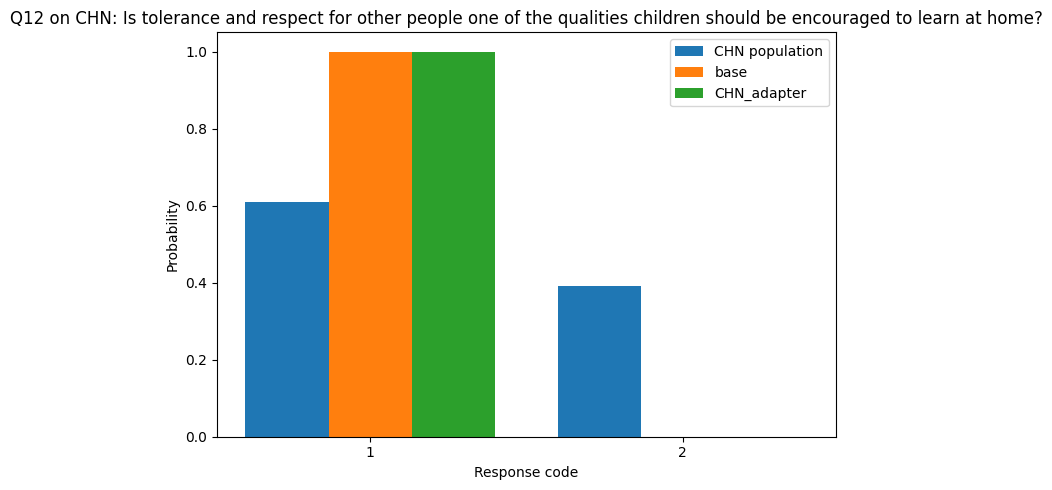

In [13]:
# Example: automatically select the first country/question pair actually present.
available_question_country_pairs = (
    option_evaluation[["eval_country", "question_id"]]
    .drop_duplicates()
    .reset_index(drop=True)
)

if available_question_country_pairs.empty:
    print("No question/country pairs are available to plot.")
else:
    example_pair = available_question_country_pairs.iloc[0]
    plot_question_distribution(
        example_pair["question_id"],
        example_pair["eval_country"],
    )


In [14]:
# Example for a matched adapter line plot:
# plot_question_distribution_lines("Q14", AVAILABLE_EVAL_COUNTRIES[0], show_option_labels=True)


In [15]:
# You can also select a specific evaluated adapter explicitly:
# plot_question_distribution_lines("Q62", AVAILABLE_EVAL_COUNTRIES[0], adapter_name=ADAPTER_MODELS[0])


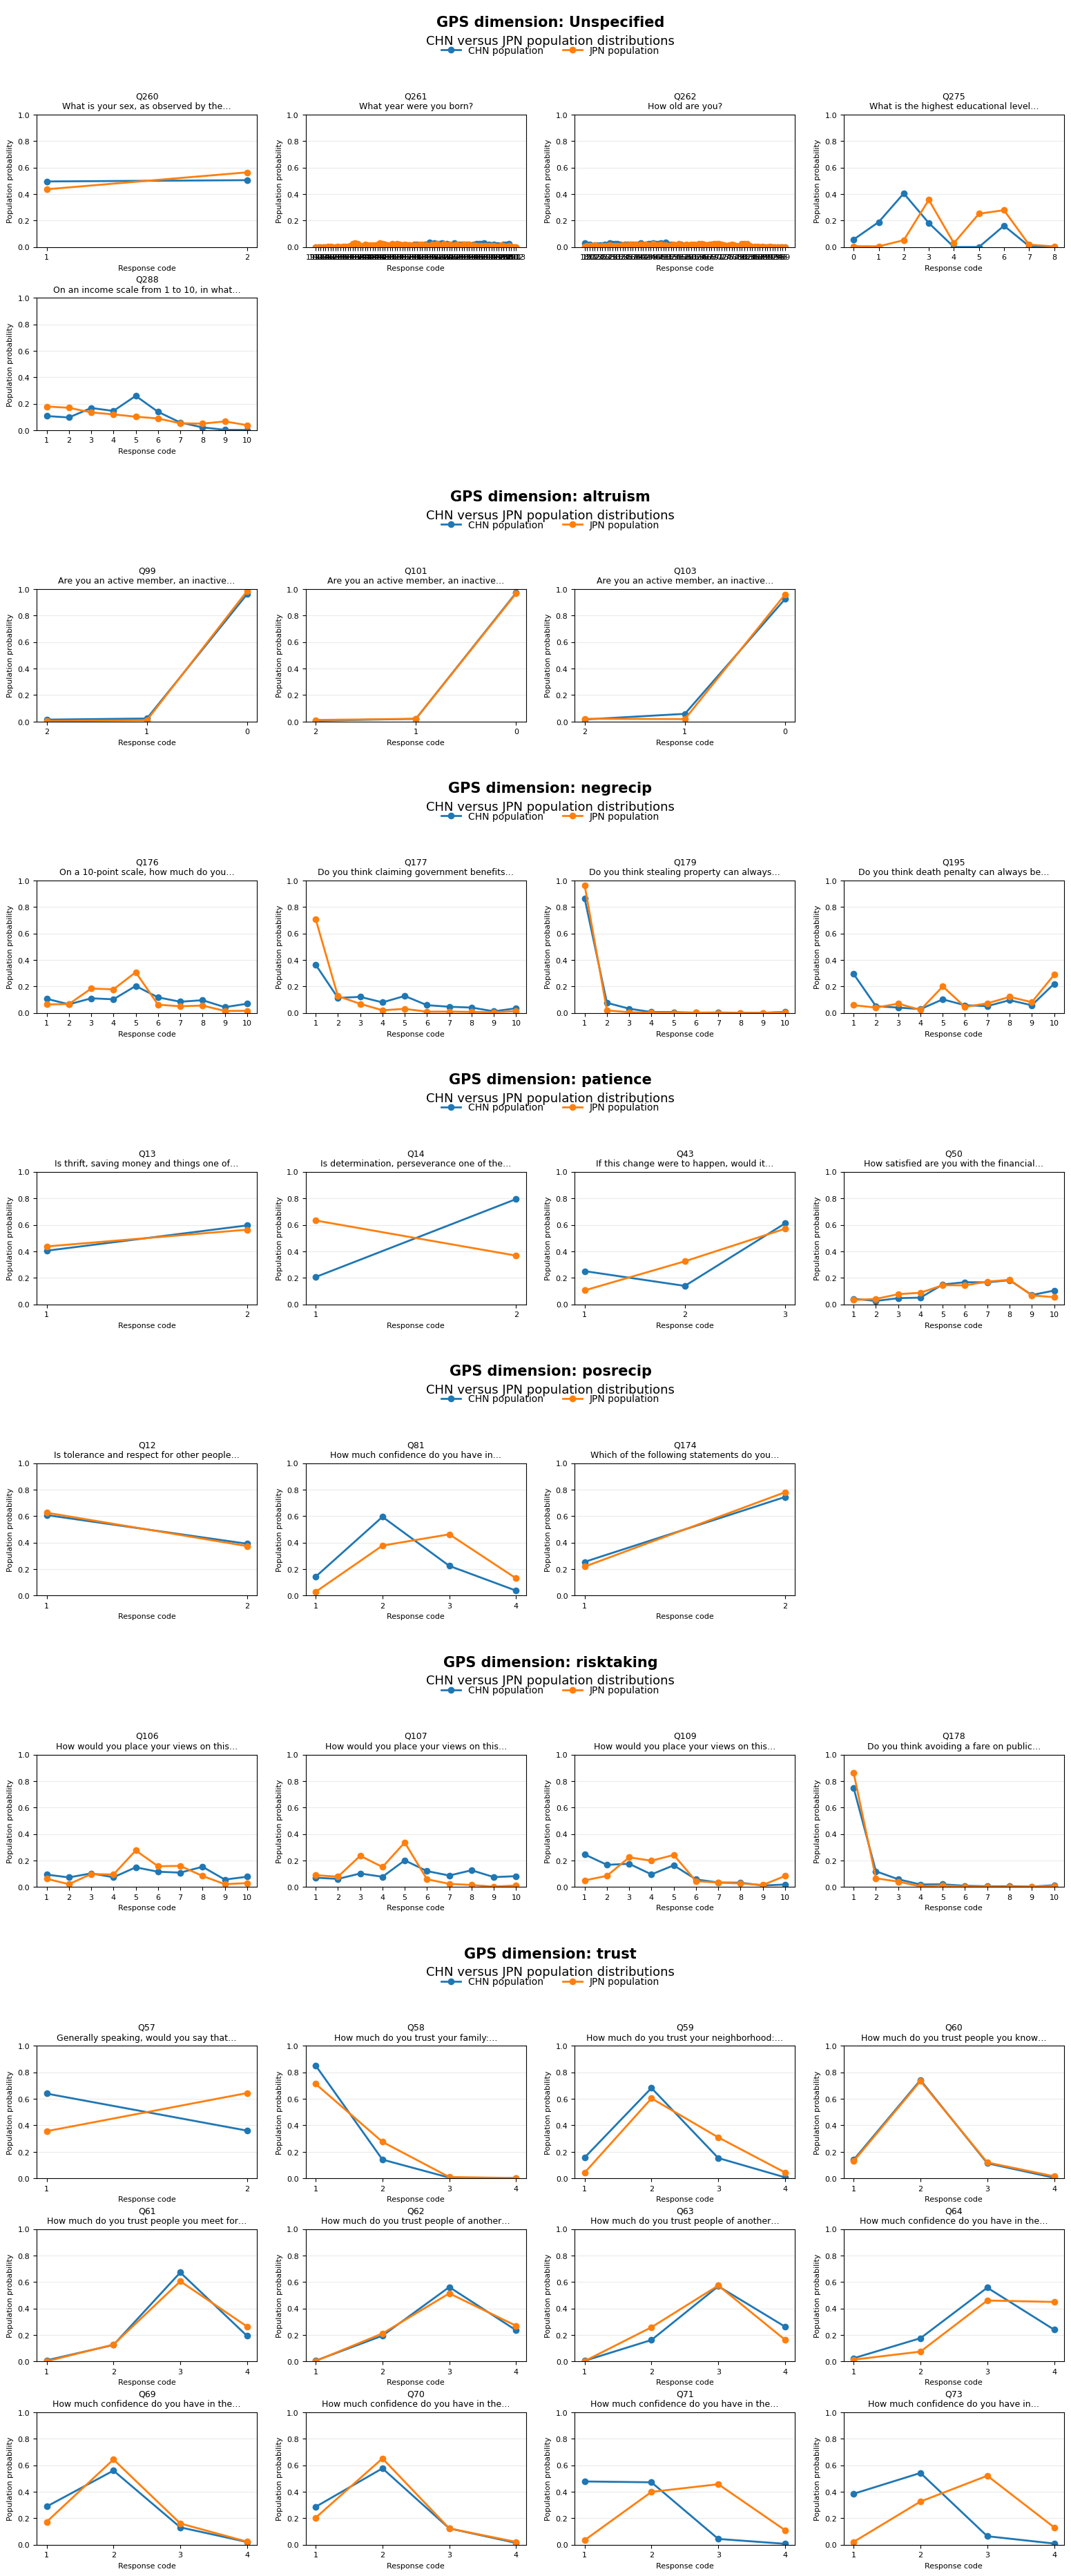

In [16]:
# Population comparison is available whenever at least two country datasets were evaluated.
if len(AVAILABLE_EVAL_COUNTRIES) >= 2:
    plot_population_comparison_by_dimension(
        country_a=AVAILABLE_EVAL_COUNTRIES[0],
        country_b=AVAILABLE_EVAL_COUNTRIES[1],
        n_columns=4,
        header_height=1.3,
    )
else:
    print("Only one evaluation country is present; skipping two-country population comparison.")


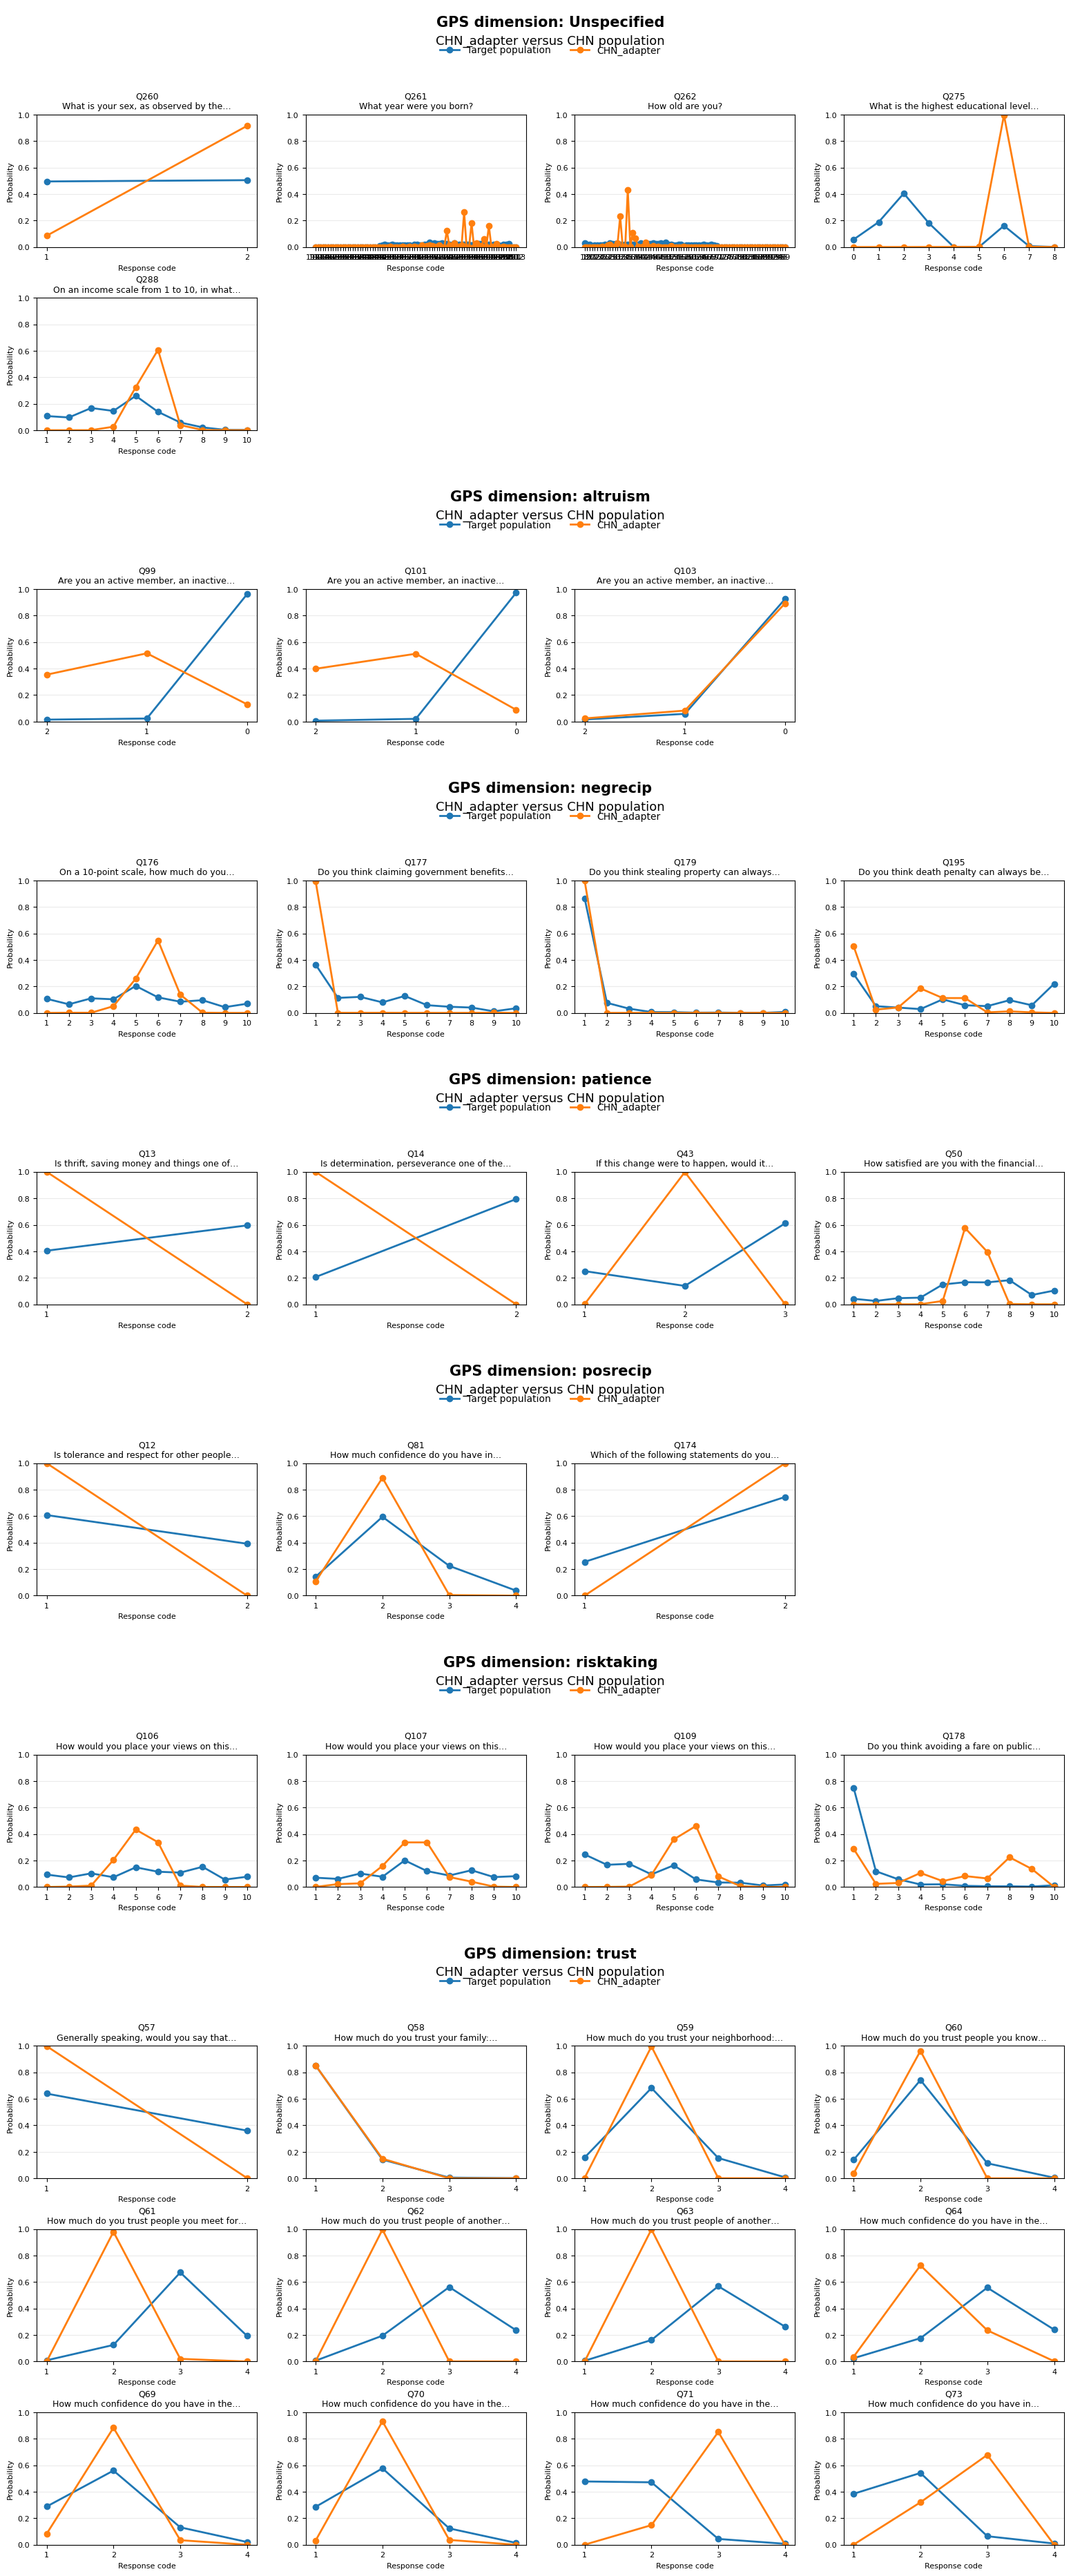

In [17]:
# Example matched-adapter grid. The matched adapter is inferred from the evaluation output.
if MATCHED_ADAPTER_MODELS:
    example_adapter = MATCHED_ADAPTER_MODELS[0]
    plot_all_question_distributions_for_adapter(
        example_adapter,
        header_height=1.3,
    )
else:
    print("No matched adapter/data combination is present in this evaluation output.")


Plotting CHN_adapter on CHN...


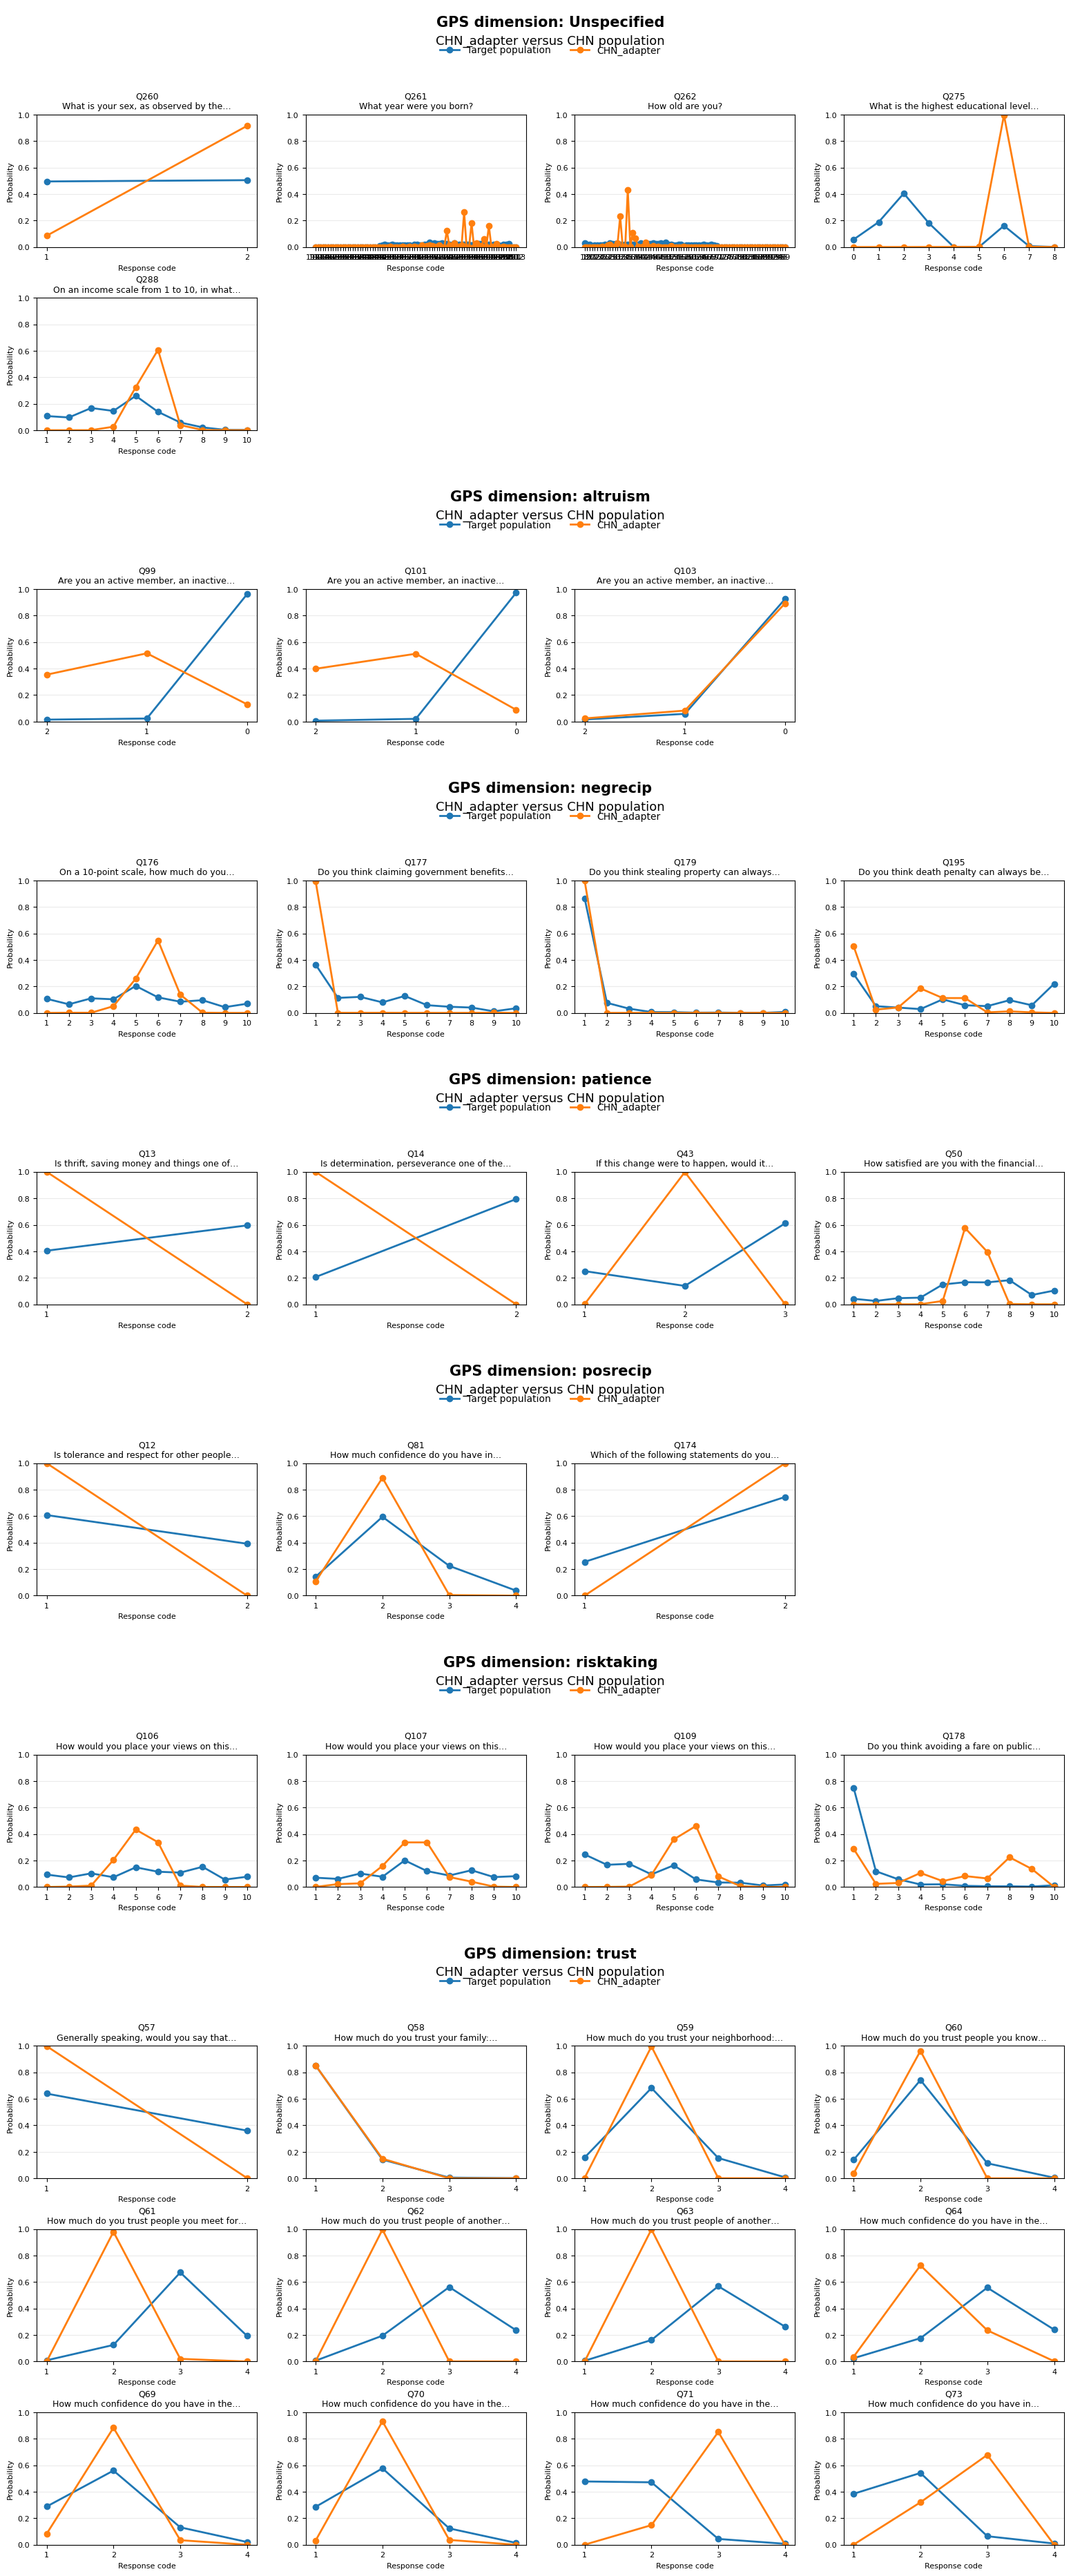

Plotting JPN_adapter on JPN...


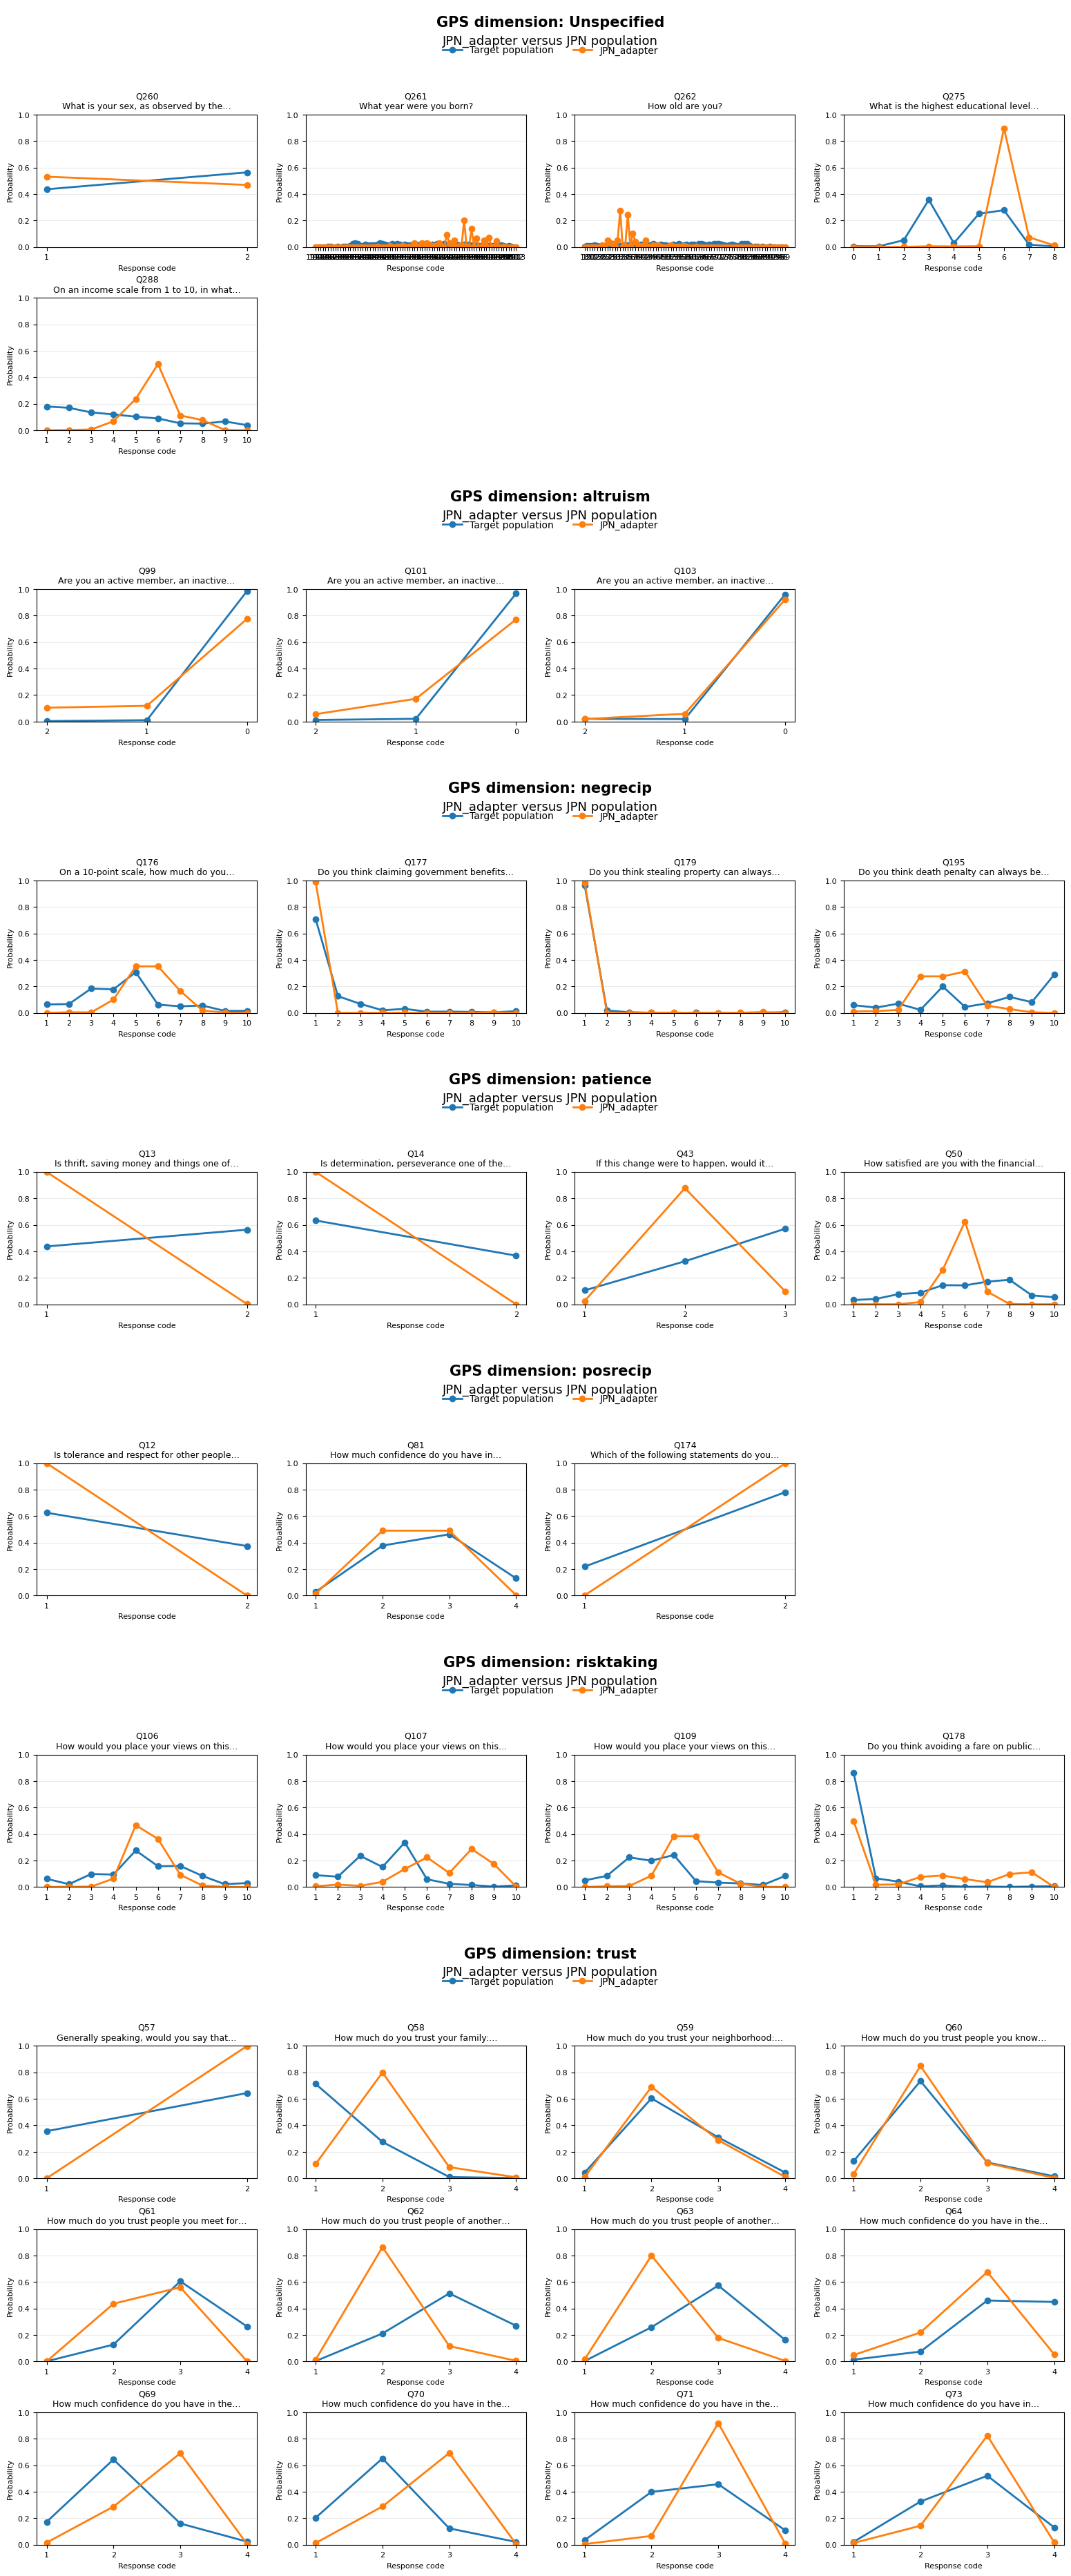

Plotting GBR_adapter on GBR...


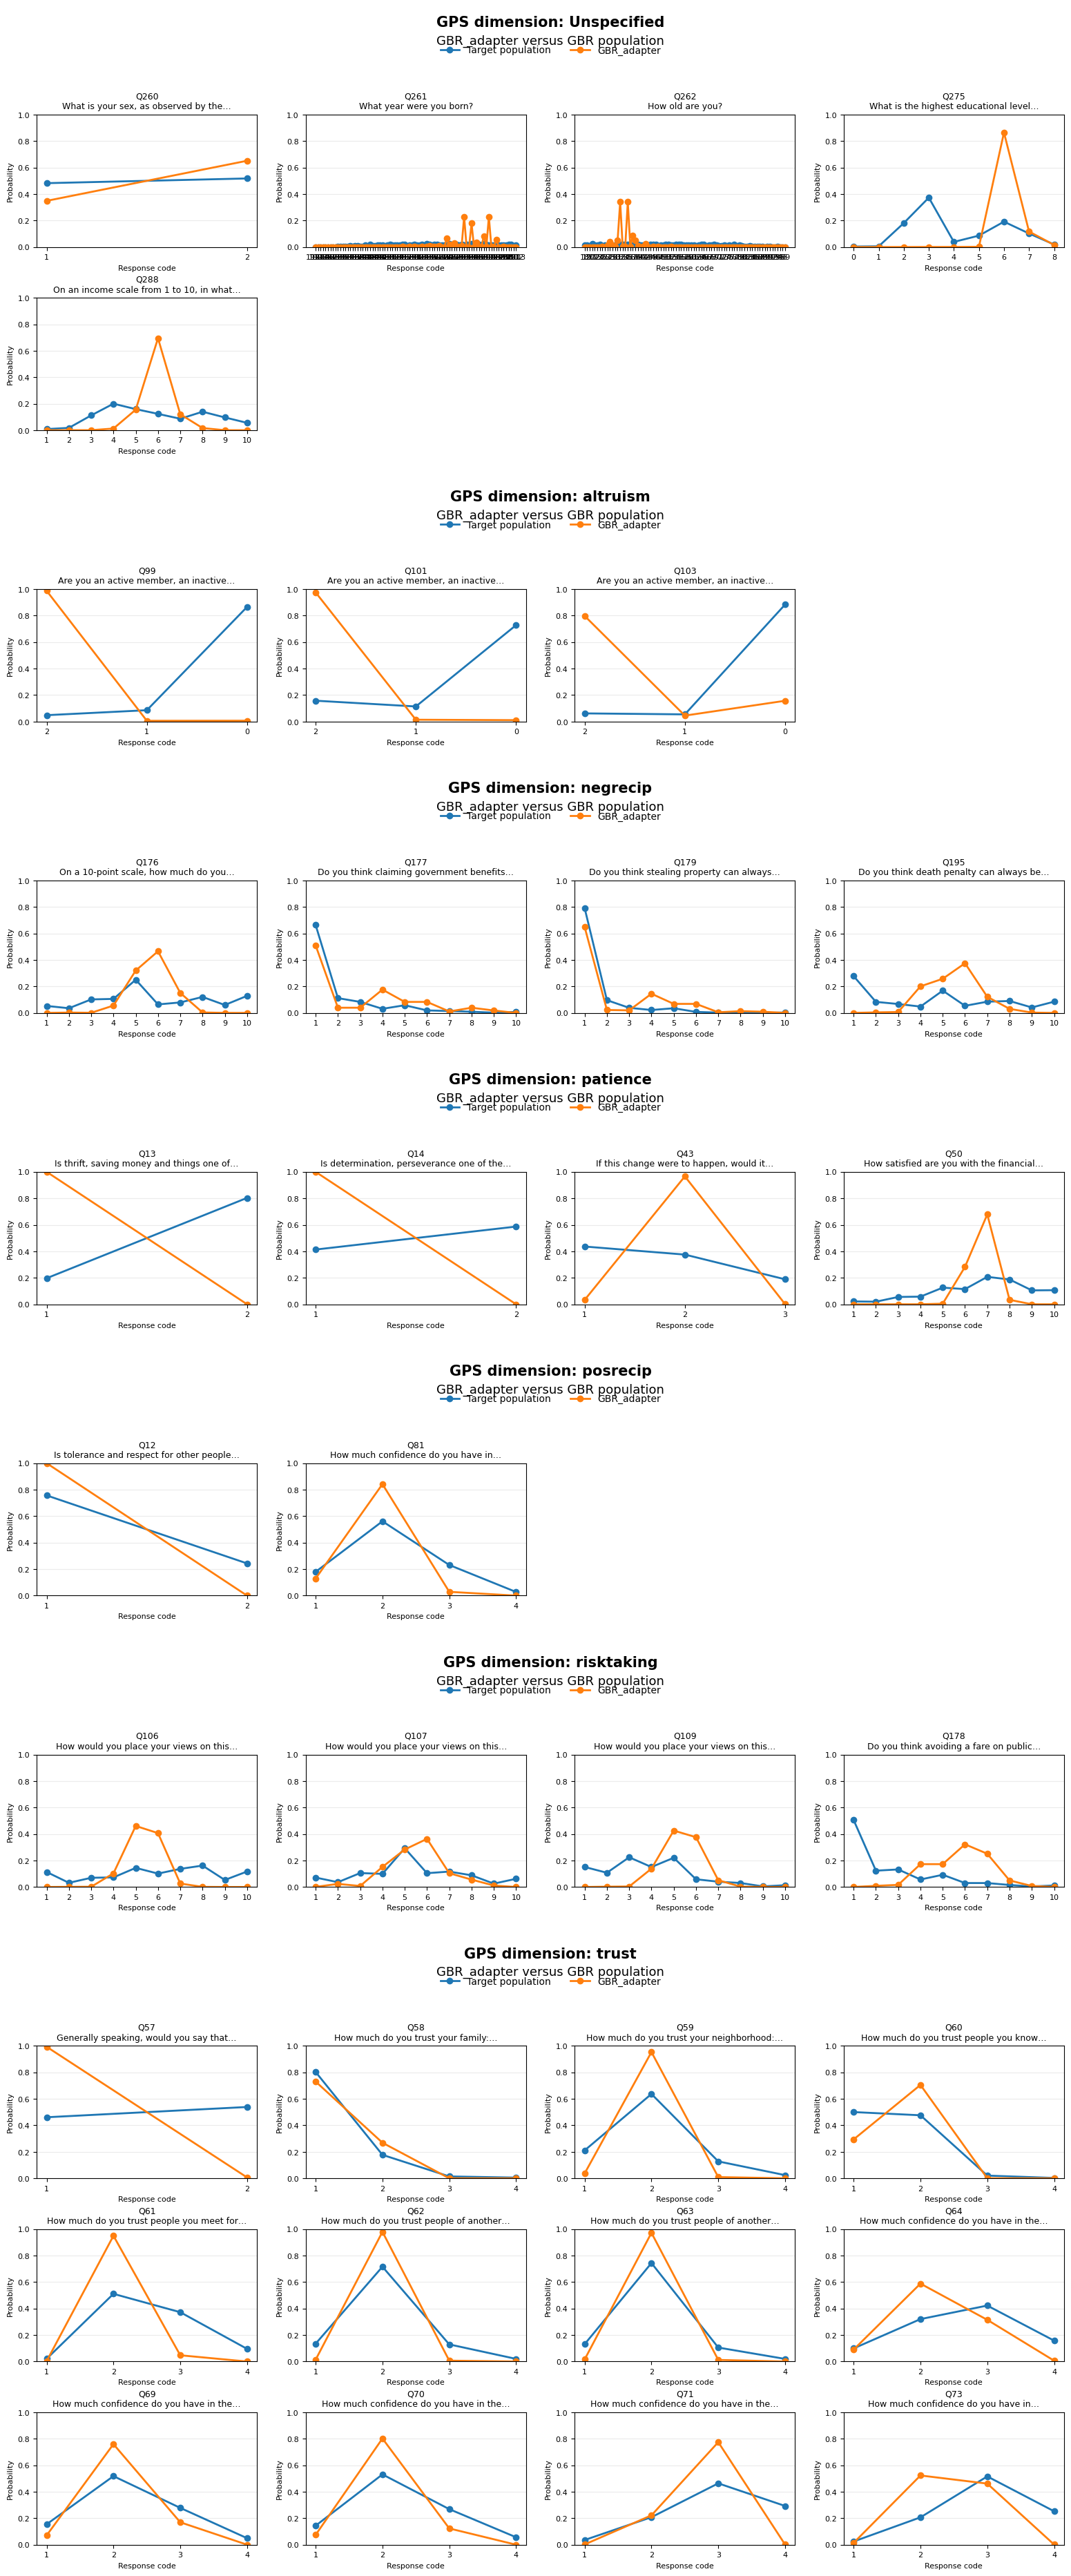

Plotting USA_adapter on USA...


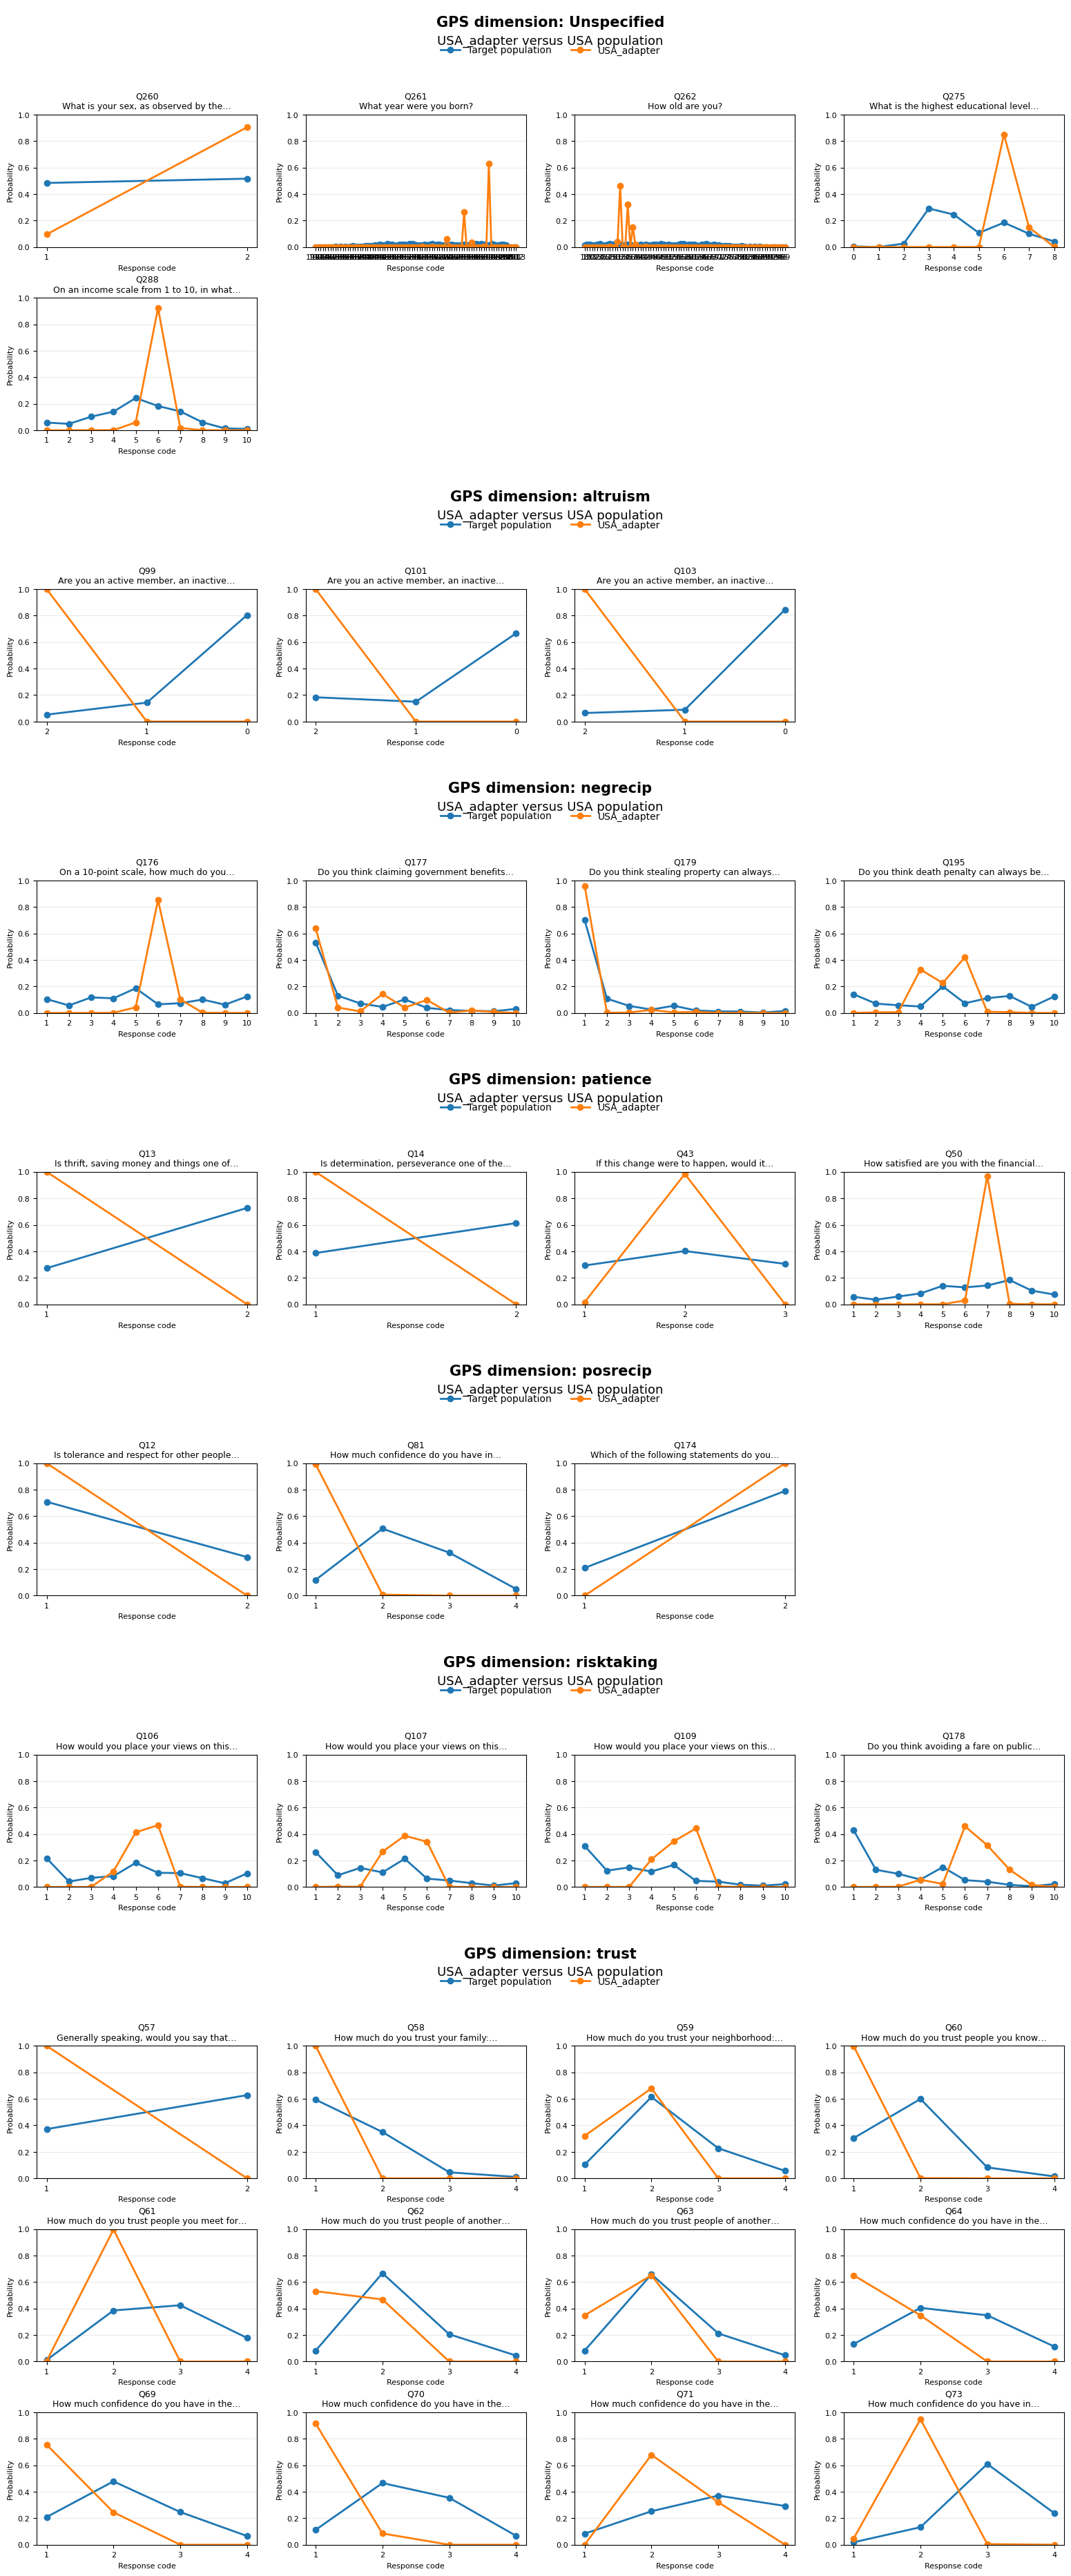

Plotting MEX_adapter on MEX...


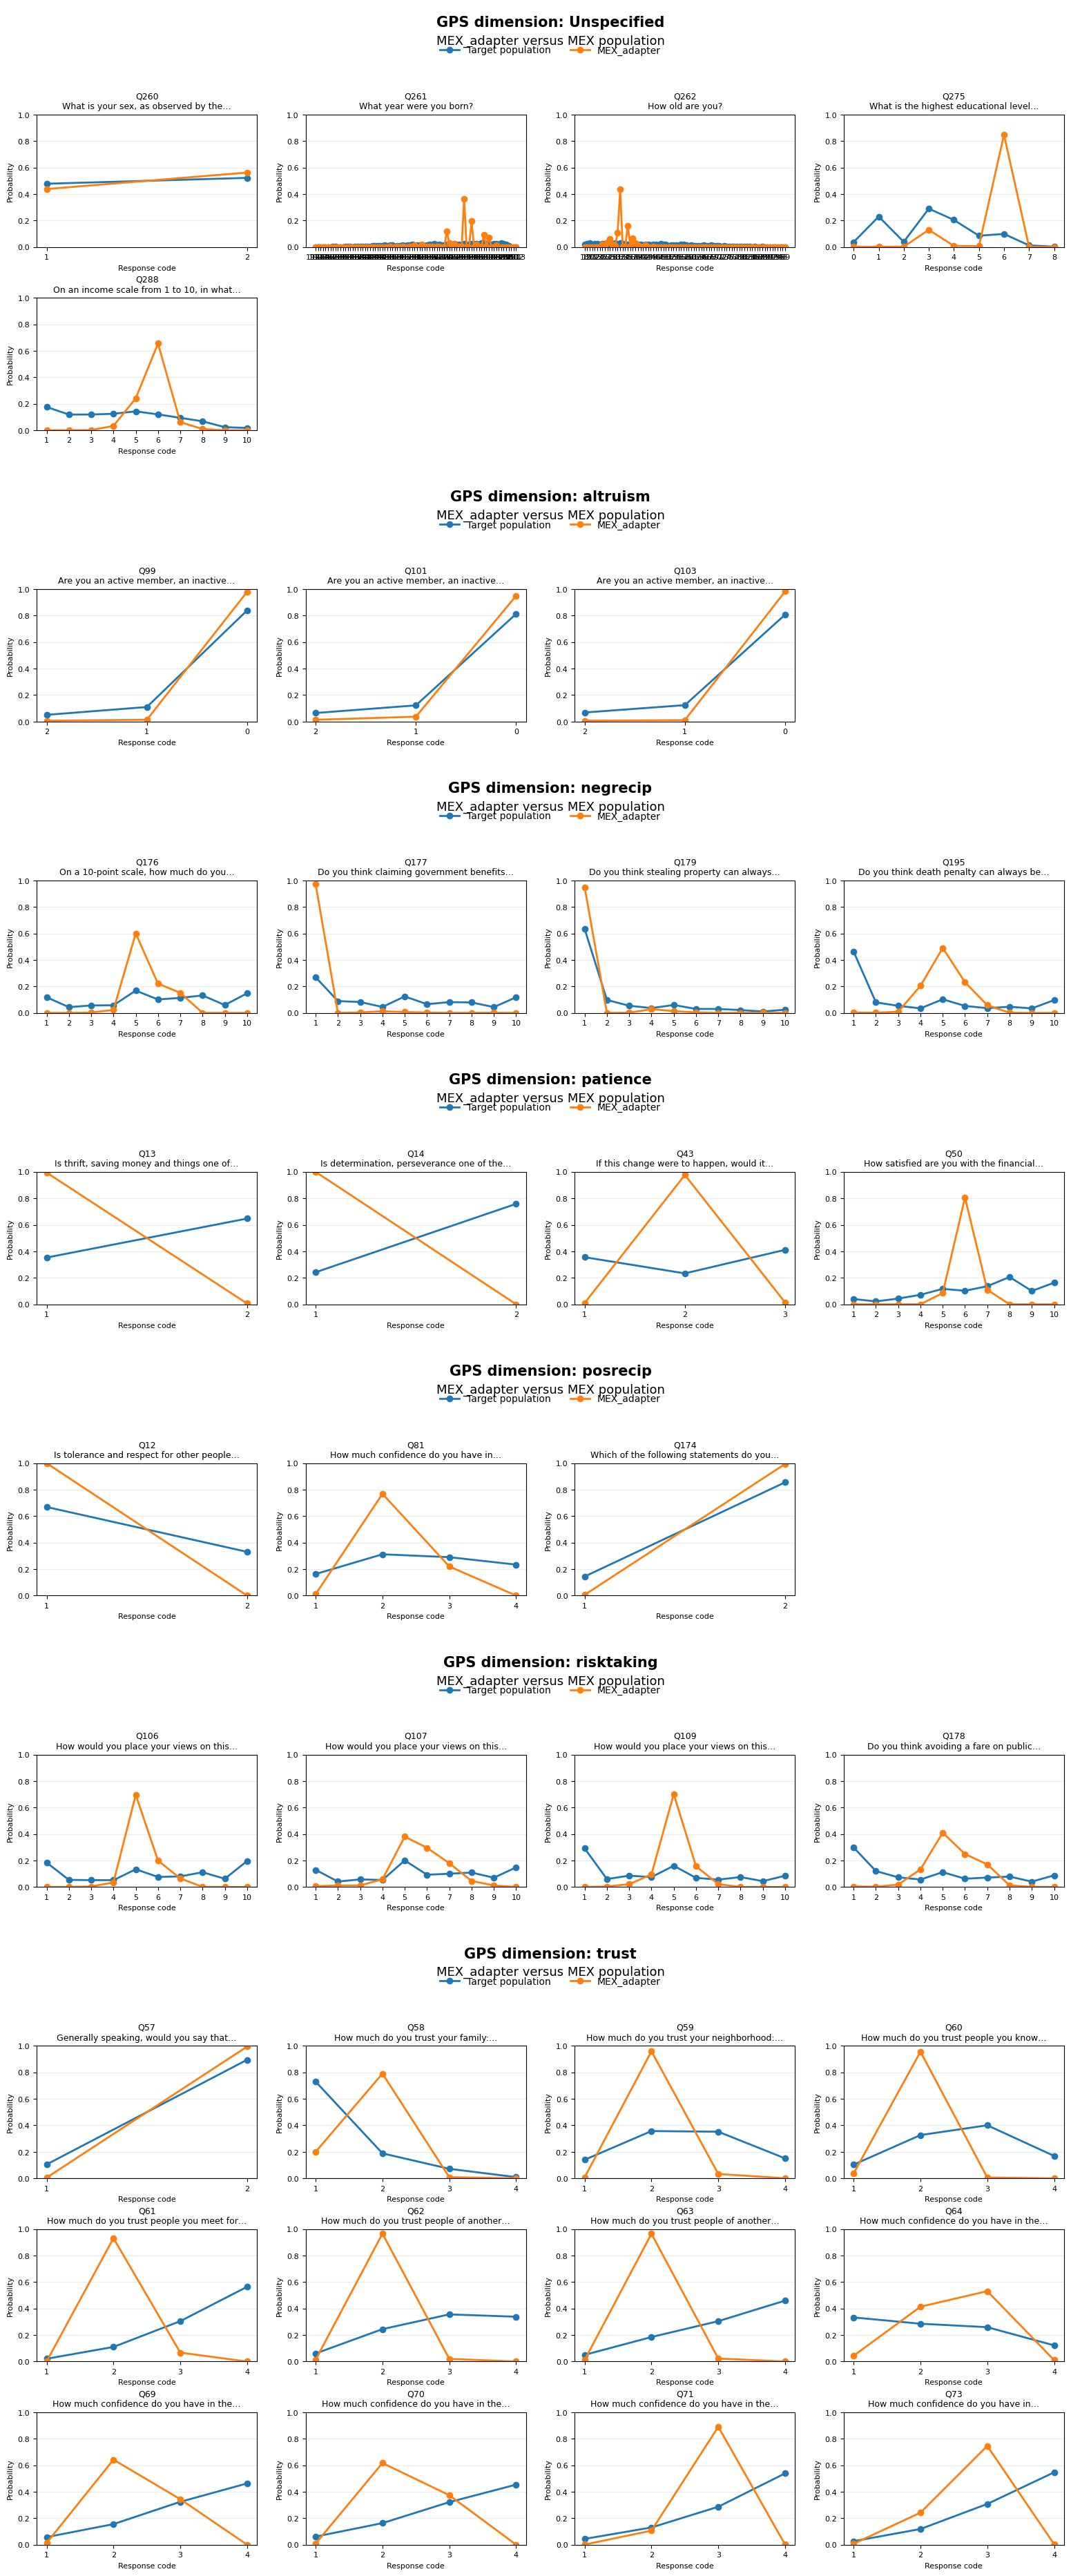

Plotting ARG_adapter on ARG...


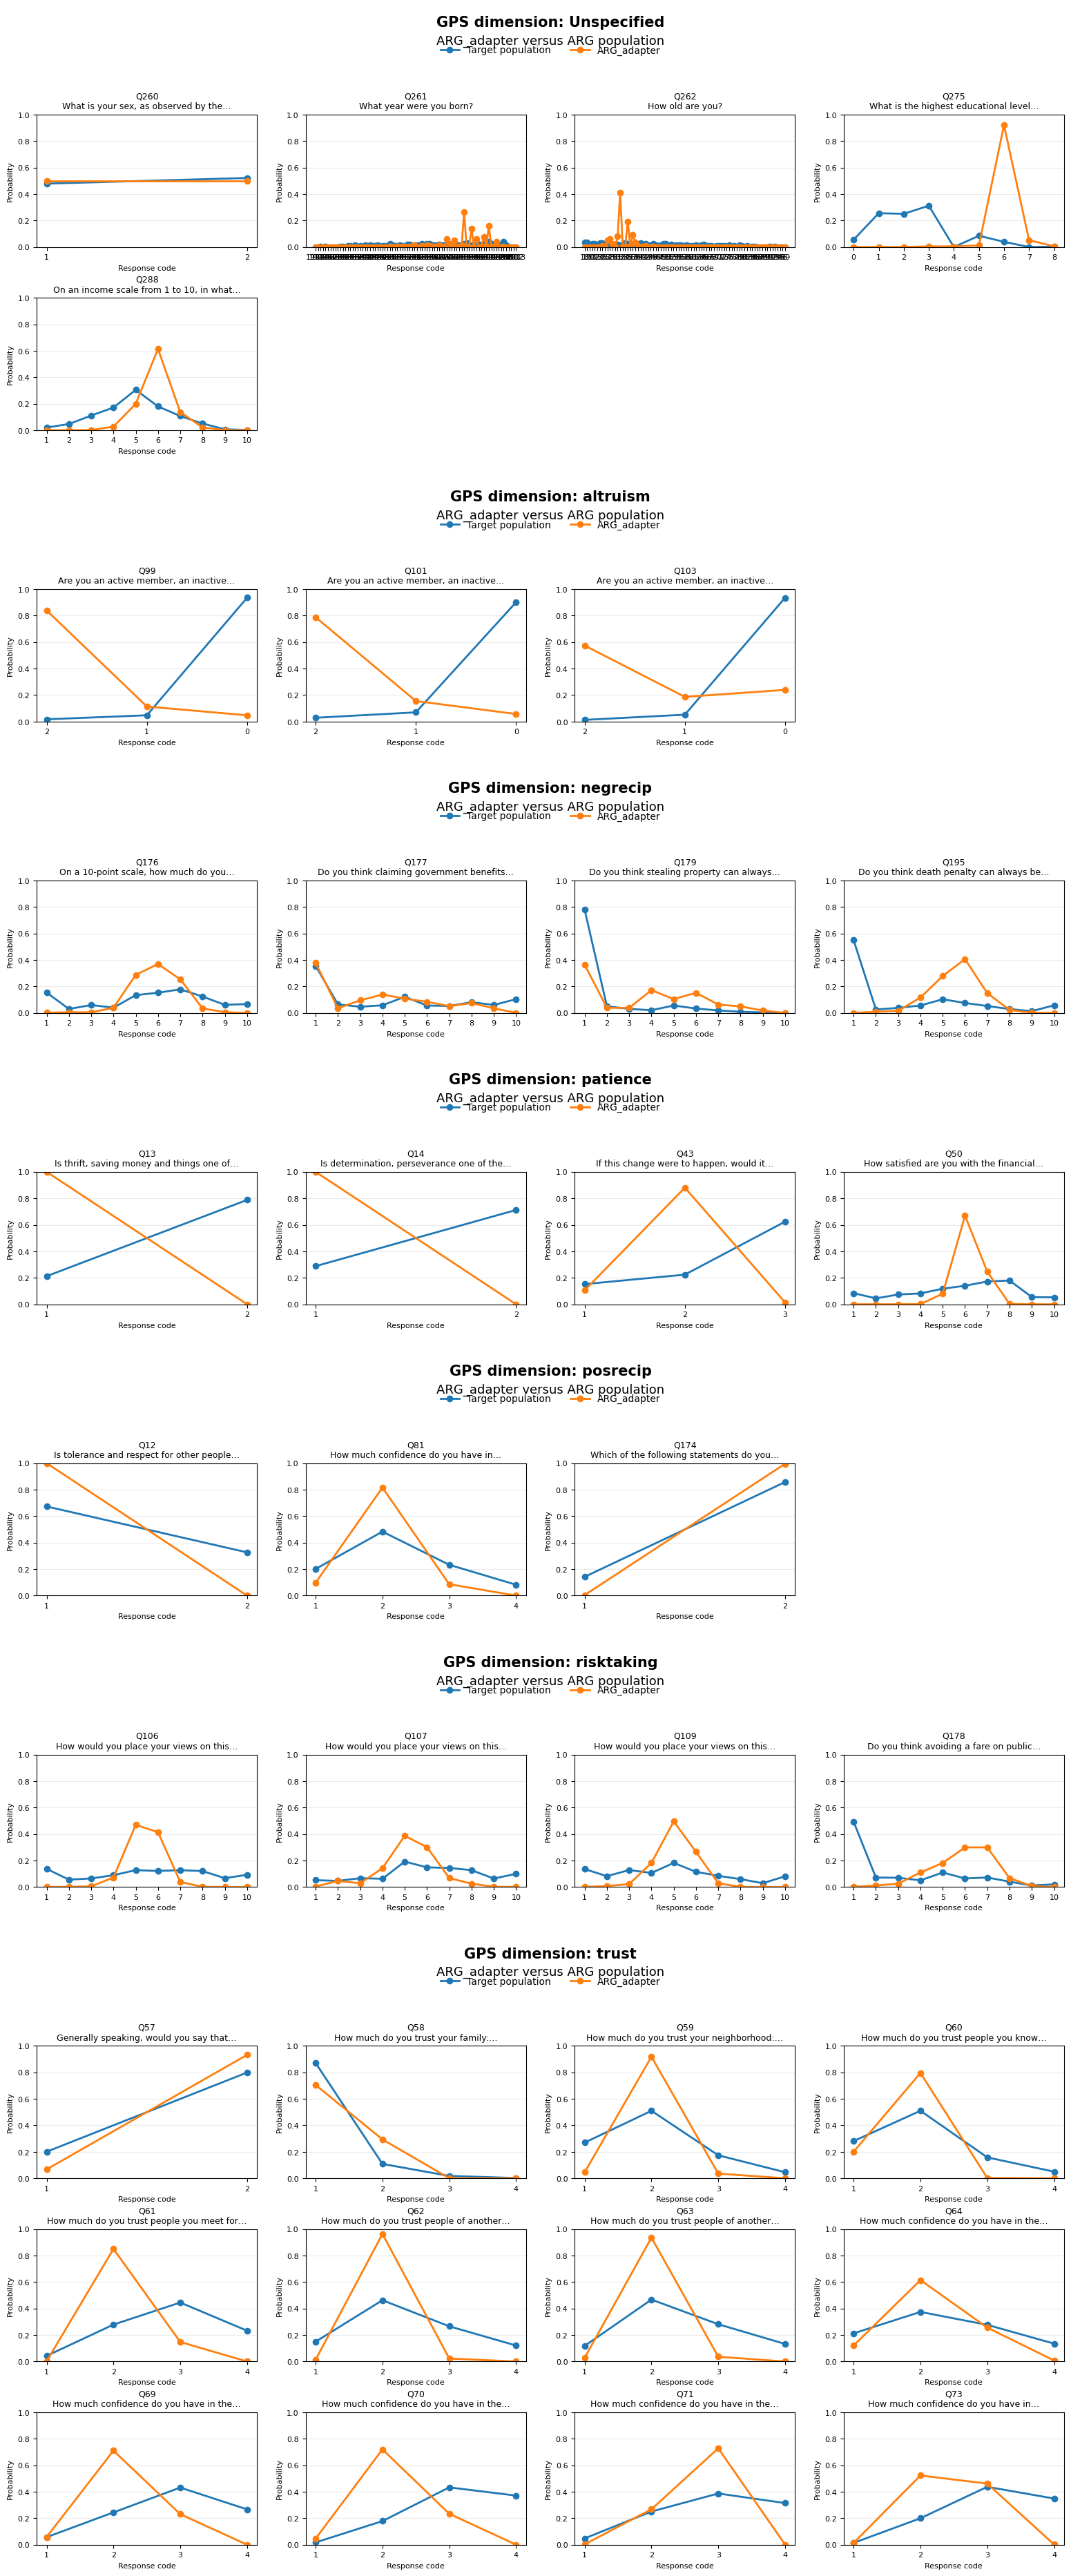

Plotting DEU_adapter on DEU...


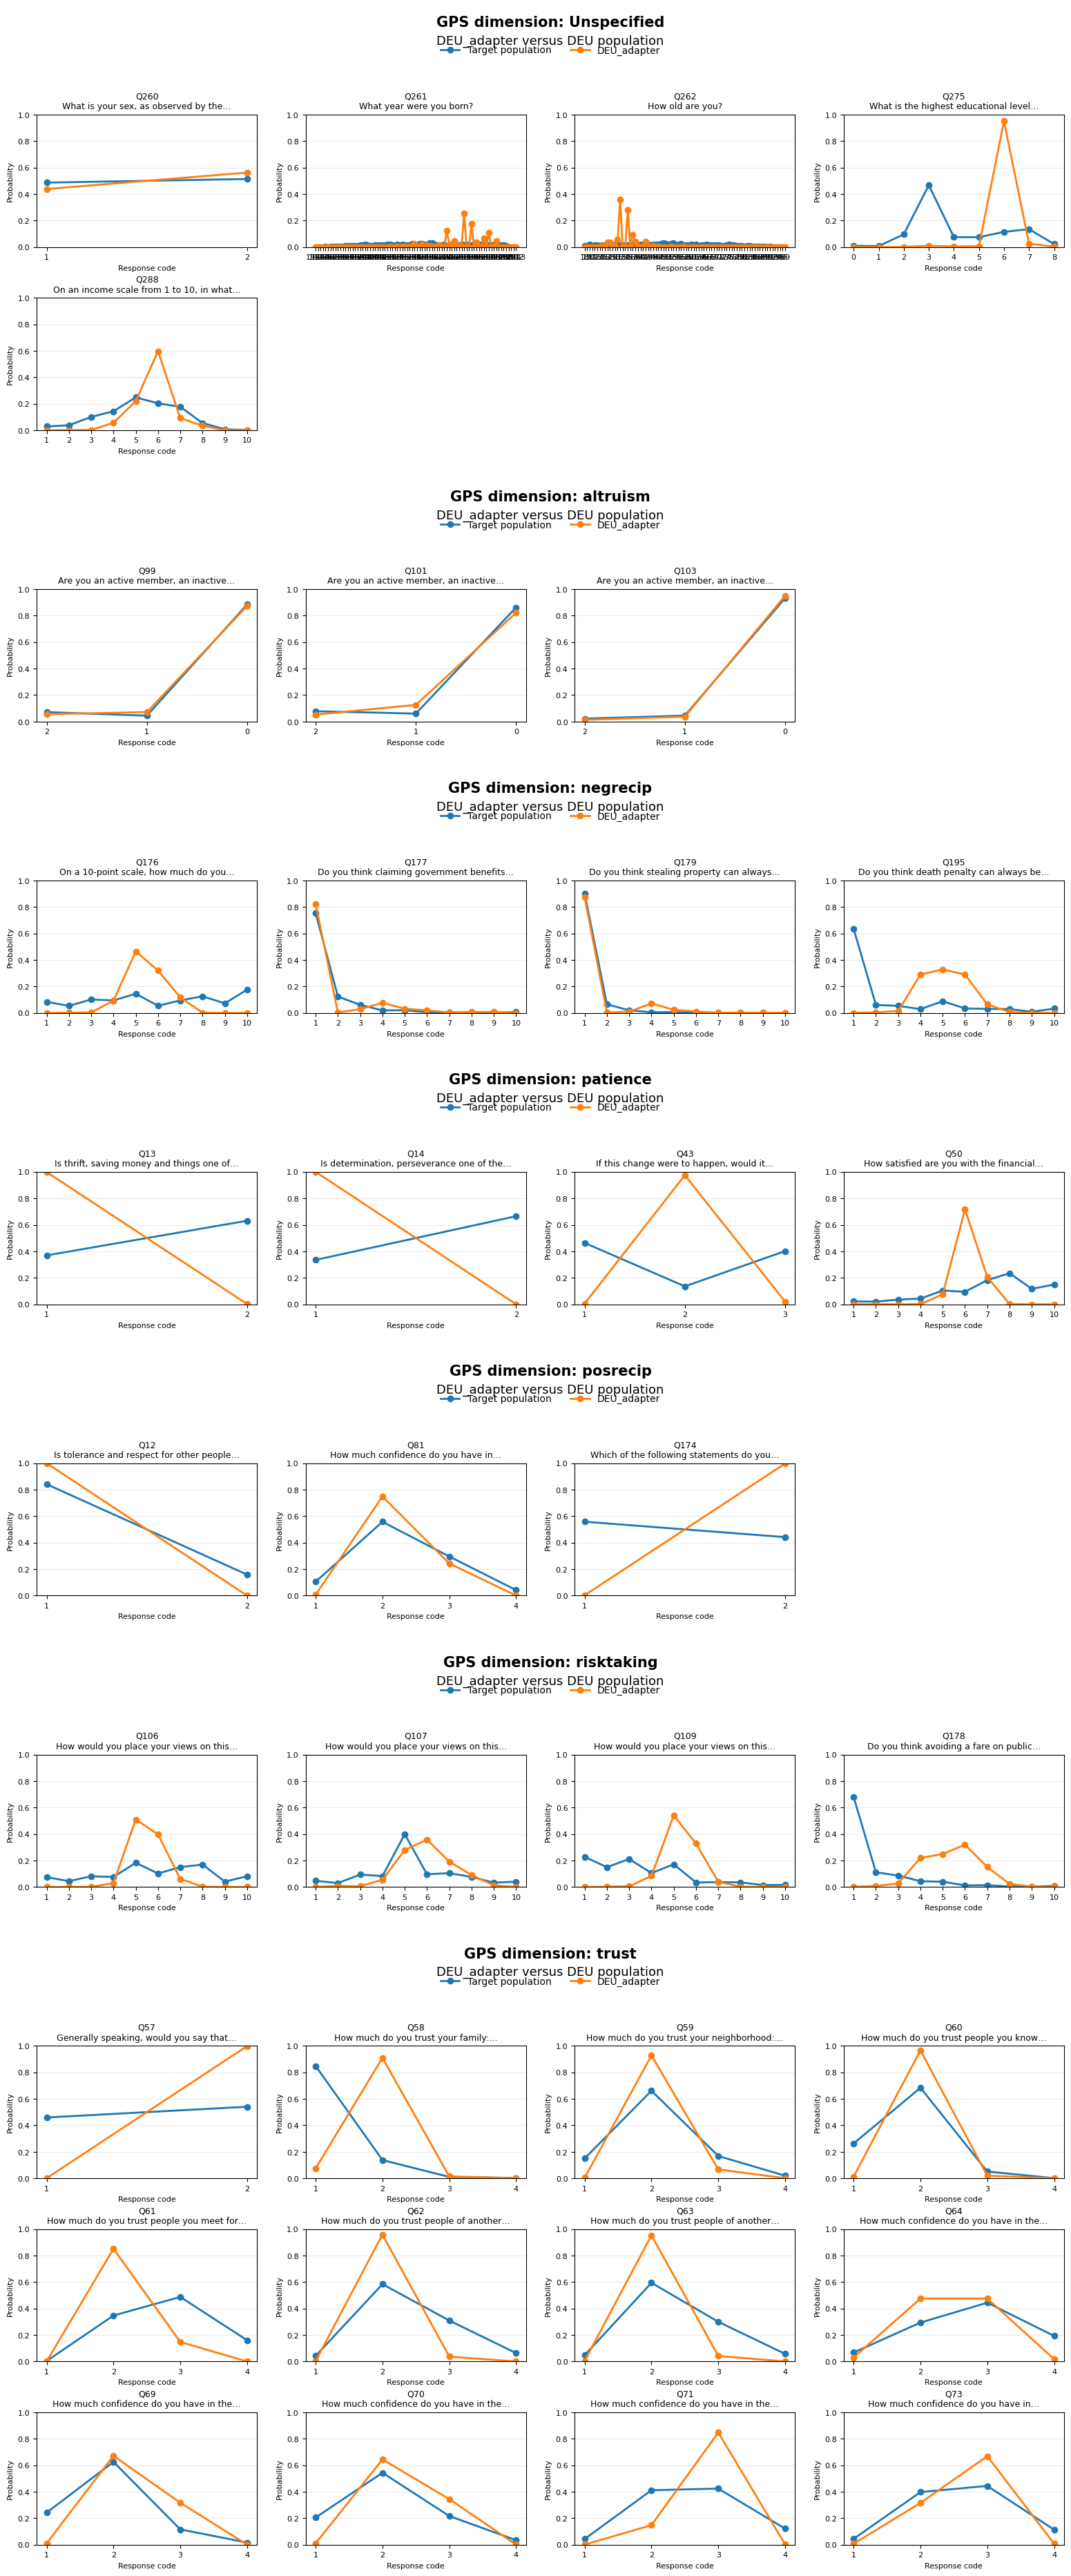

Plotting RUS_adapter on RUS...


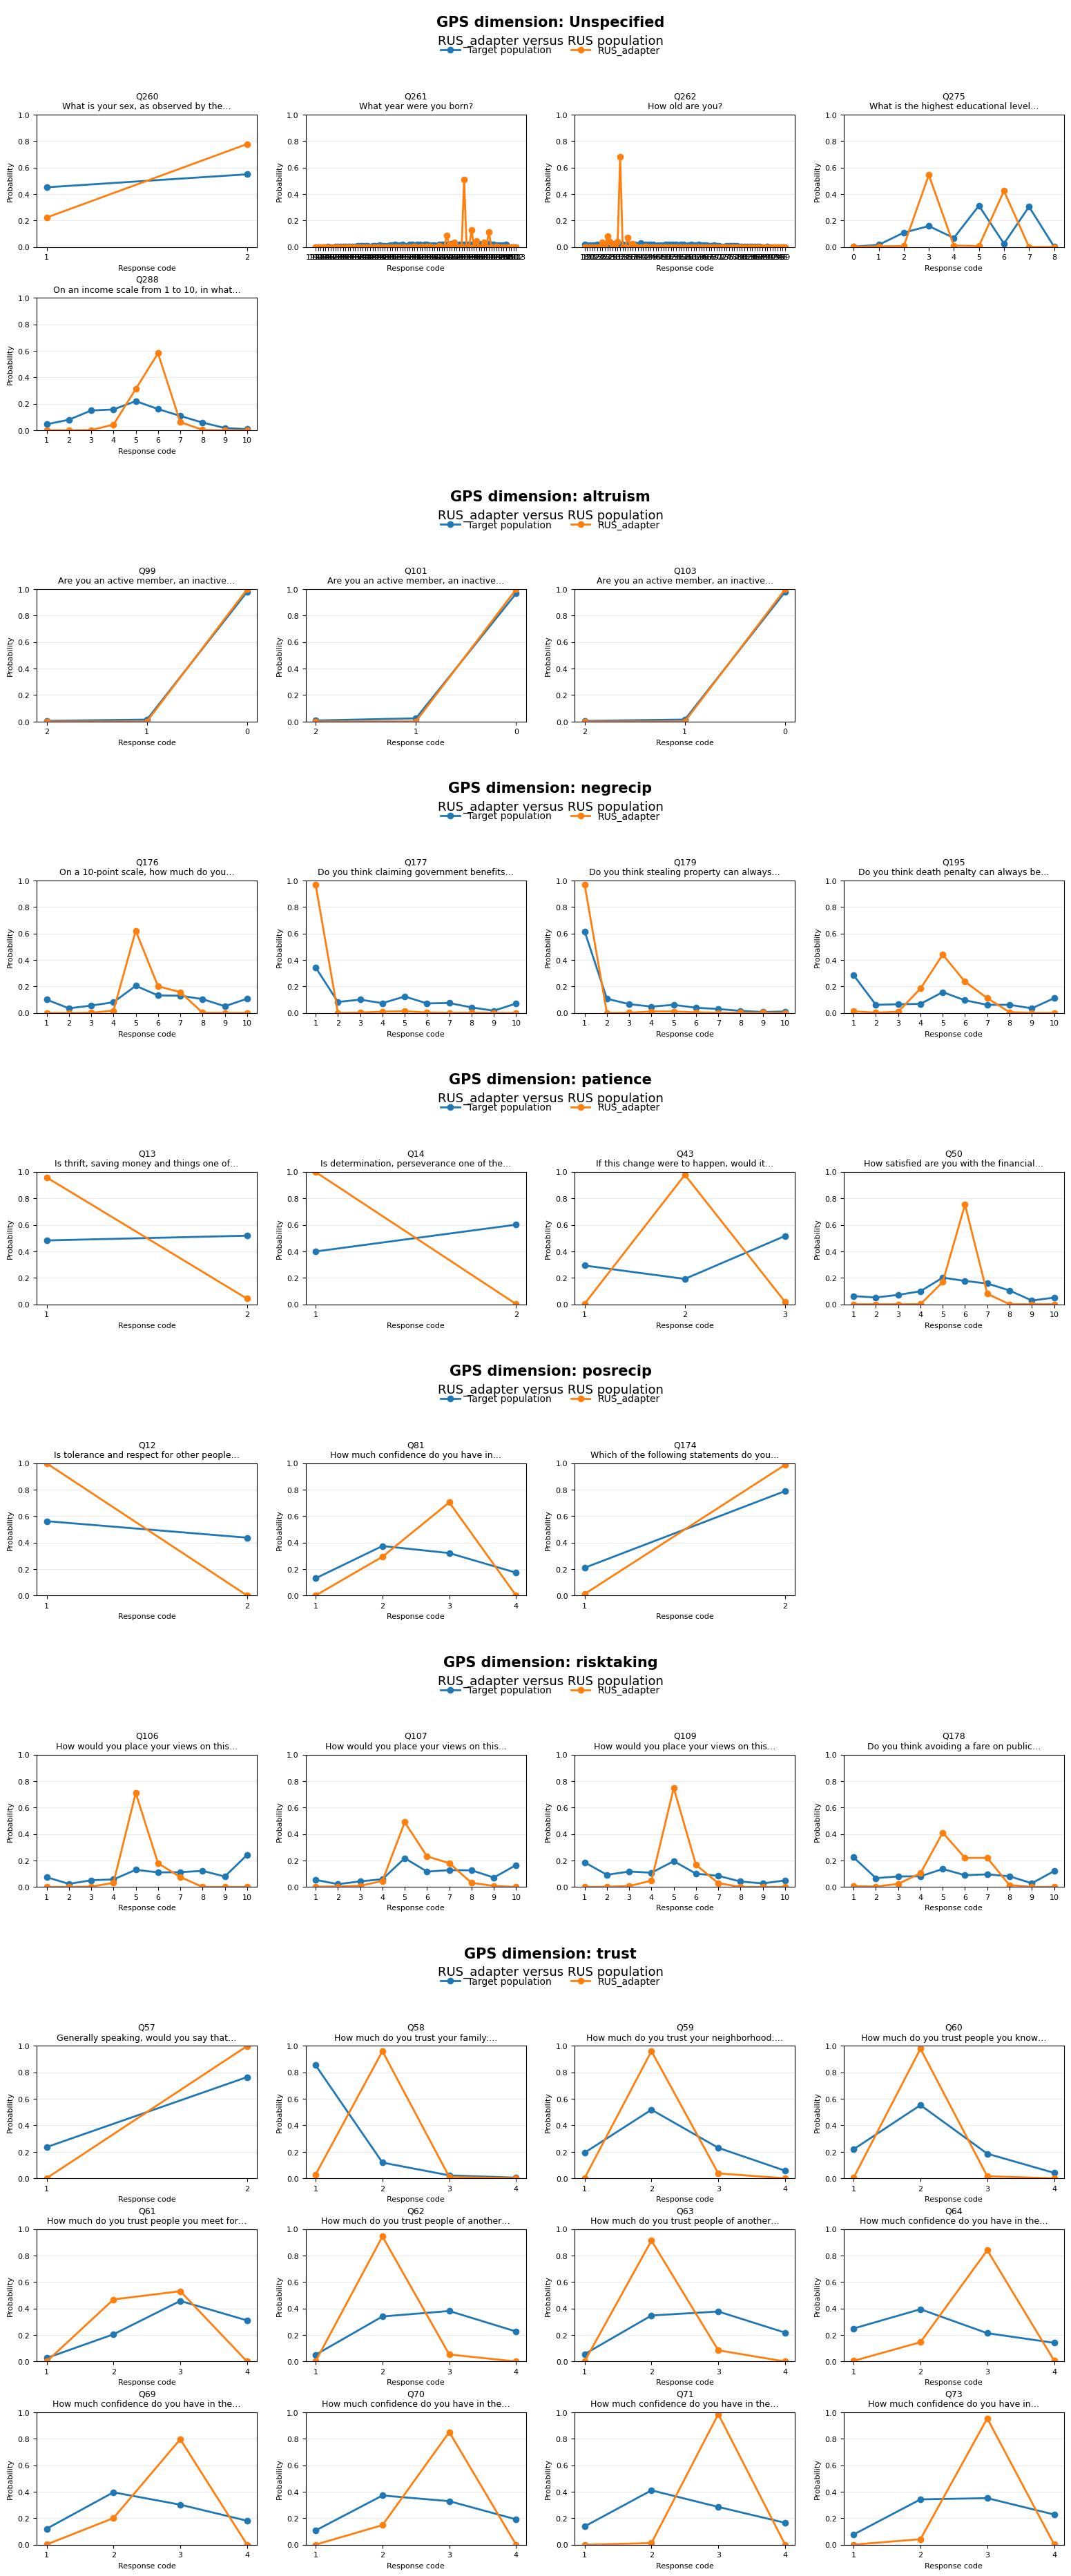

In [21]:
# Optional: generate the full question grid for every matched adapter in the run.
# This can create many large figures when numerous countries are present, so it is off by default.
PLOT_ALL_MATCHED_ADAPTER_GRIDS = True

if PLOT_ALL_MATCHED_ADAPTER_GRIDS:
    for adapter_name in MATCHED_ADAPTER_MODELS:
        print(f"Plotting {adapter_name} on {ADAPTER_TO_MATCHED_COUNTRY[adapter_name]}...")
        plot_all_question_distributions_for_adapter(
            adapter_name,
            header_height=1.3,
        )
else:
    print(
        "Available matched adapter grids:", MATCHED_ADAPTER_MODELS,
        "\nSet PLOT_ALL_MATCHED_ADAPTER_GRIDS=True to render all of them."
    )


In [19]:
gps_base_improvement_summary

,model,eval_country,relationship,gps_dimension,metric,mean_improvement_over_base,median_improvement_over_base,ci_2.5%,ci_97.5%,fraction_questions_improved,n_questions
0,CHN_adapter,CHN,matched,posrecip,tv_distance,-0.033833,-0.007013,-0.094412,-0.000074,0.00,3
1,CHN_adapter,CHN,matched,posrecip,js_divergence,-0.027265,-0.013916,-0.067543,-0.000337,0.00,3
2,CHN_adapter,CHN,matched,posrecip,brier_score,-0.030150,-0.007051,-0.083283,-0.000116,0.00,3
3,CHN_adapter,CHN,matched,posrecip,cross_entropy,-1.271310,-1.060685,-1.958889,-0.794357,0.00,3
4,CHN_adapter,CHN,matched,posrecip,wasserstein_distance,-0.047905,-0.047905,-0.095735,-0.000074,0.00,2
...,...,...,...,...,...,...,...,...,...,...,...
387,RUS_adapter,RUS,matched,Unspecified,brier_score,-0.042657,-0.103858,-0.247733,0.233310,0.20,5
388,RUS_adapter,RUS,matched,Unspecified,cross_entropy,-1.870135,-0.831844,-3.330091,-0.419818,0.00,5
389,RUS_adapter,RUS,matched,Unspecified,wasserstein_distance,-0.940731,-1.040527,-2.166612,0.285151,0.25,4
390,RUS_adapter,RUS,matched,Unspecified,abs_mean_error,-0.636855,-0.467742,-1.707121,0.433411,0.50,4


In [20]:
metric_choice = "wasserstein_distance"

if gps_base_improvement_summary.empty:
    print("No GPS-dimension adapter-vs-base improvement summary is available for this run.")
elif "metric" not in gps_base_improvement_summary.columns:
    print("GPS improvement summary does not contain a 'metric' column.")
elif metric_choice not in set(gps_base_improvement_summary["metric"].dropna().astype(str)):
    print(
        f"Metric {metric_choice!r} is not available. Available metrics: "
        f"{sorted(gps_base_improvement_summary['metric'].dropna().astype(str).unique())}"
    )
else:
    display(
        gps_base_improvement_summary.loc[
            gps_base_improvement_summary["metric"].astype(str).eq(metric_choice)
        ]
        .groupby(["model", "eval_country", "gps_dimension"])["mean_improvement_over_base"]
        .mean()
    )


model        eval_country  gps_dimension
ARG_adapter  ARG           Unspecified     -0.697237
                           altruism        -0.553909
                           negrecip         0.078237
                           patience        -0.020096
                           posrecip        -0.011014
                           risktaking      -0.137536
                           trust           -0.000677
CHN_adapter  CHN           Unspecified     -0.290737
                           altruism         0.177050
                           negrecip        -0.309770
                           patience        -0.026967
                           posrecip        -0.047905
                           risktaking       0.080448
                           trust           -0.033206
DEU_adapter  DEU           Unspecified     -0.194817
                           altruism         0.861078
                           negrecip         0.107380
                           patience        -0.055743
                           posrecip         0.022648
                           risktaking      -0.023550
                           trust           -0.099145
GBR_adapter  GBR           Unspecified     -1.055953
                           altruism        -0.796797
                           negrecip        -0.388364
                           patience         0.009243
                           posrecip        -0.024051
                           risktaking      -0.069975
                           trust           -0.033842
JPN_adapter  JPN           Unspecified      0.743637
                           altruism         0.827204
                           negrecip        -0.128920
                           patience        -0.004067
                           posrecip         0.189947
                           risktaking       0.220661
                           trust           -0.039851
MEX_adapter  MEX           Unspecified     -0.710294
                           altruism         0.620565
                           negrecip        -0.277119
                           patience        -0.077593
                           posrecip         0.012817
                           risktaking      -0.203258
                           trust           -0.011444
RUS_adapter  RUS           Unspecified     -0.940731
                           altruism         1.005360
                           negrecip        -0.292474
                           patience        -0.048186
                           posrecip         0.040333
                           risktaking      -0.263792
                           trust           -0.157705
USA_adapter  USA           Unspecified     -2.116111
                           altruism        -0.934792
                           negrecip        -0.176181
                           patience        -0.120889
                           posrecip        -0.480256
                           risktaking      -0.150826
                           trust           -0.477084
Name: mean_improvement_over_base, dtype: float64